- 线性回归
- 前向传播（预测值）【推理】
- 反向传播（误差）
- 链式求导
- 梯度下降法（随机梯度下降、批量梯度下降、小批量梯度下降）
- 
- L1,L2正则化
- 动量法

# 线性回归

## 基本概念与理论

线性回归是一种通过**拟合自变量（特征）与因变量（标签）之间的线性关系**，来进行预测的监督学习算法。

其核心是一个线性方程。 如**一元线性回归**：`y = w*x + b`  
- `y` 是我们要预测的目标值。  
- `x` 是输入的特征。  
- `w` 是**权重**，代表特征 `x` 对目标 `y` 的影响程度。  
- `b` 是**偏置项**，代表当特征 `x` 为 0 时的基准值。  

**“最佳拟合”**：线性回归的目标是找到一组参数（`w, b`），使得这条直线能够**尽可能地穿过所有数据点**，即让**真实值($y$)** 与 **预测值($\hat{y}$)** 之间的 **残差($y-\hat{y}$)** 最小。

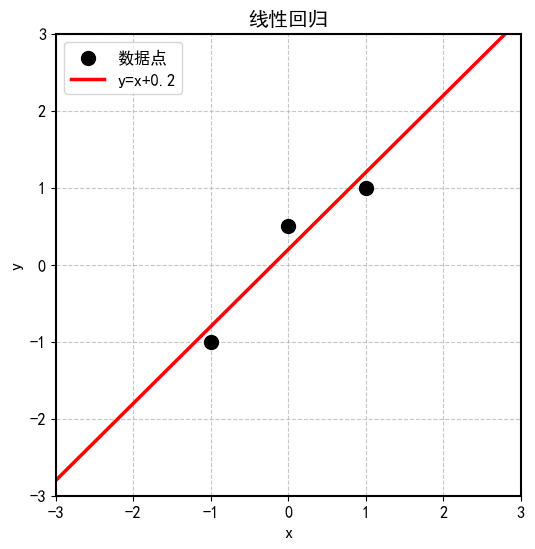

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 设置中文字体和负号显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建图形
plt.figure(figsize=(6, 6))

# 数据点
x_points = [1, 0, -1]
y_points = [1, 0.5, -1]

# 绘制数据点
plt.scatter(x_points, y_points, color='k', s=100, zorder=5, label='数据点')

# 生成x值范围
x = np.linspace(-3, 3, 100)

# 绘制第一条直线 l1: k=1, b=2
y1 = x + 0.2
plt.plot(x, y1, 'r-', label='y=x+0.2')

# 设置坐标轴范围
plt.xlim(-3, 3)
plt.ylim(-3, 3)

# 添加图例
plt.legend(loc='best')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和坐标轴标签
plt.title('线性回归')
plt.xlabel('x')
plt.ylabel('y')

# 显示图形
plt.show()

## 残差

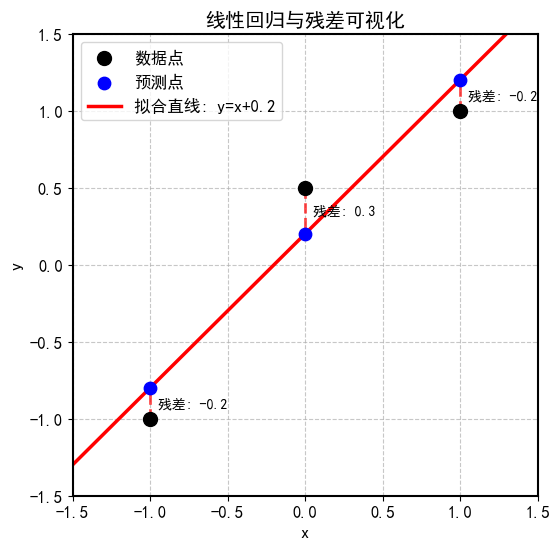

In [17]:
# 创建图形
plt.figure(figsize=(6, 6))

# 数据点
x_points = [1, 0, -1]
y_points = [1, 0.5, -1]

# 计算预测值 (使用直线 y = x + 0.2)
y_pred = [x + 0.2 for x in x_points]

# 绘制数据点
plt.scatter(x_points, y_points, color='k', s=100, zorder=5, label='数据点')

# 绘制预测点
plt.scatter(x_points, y_pred, color='blue', s=80, zorder=5, label='预测点')

# 绘制残差线
for i in range(len(x_points)):
    plt.plot([x_points[i], x_points[i]], [y_points[i], y_pred[i]], 
             'r--', linewidth=2, alpha=0.7)
    # 添加残差标签
    mid_y = (y_points[i] + y_pred[i]) / 2
    plt.text(x_points[i] + 0.05, mid_y, f'残差: {y_points[i]-y_pred[i]:.1f}', 
             fontsize=10, verticalalignment='center')

# 生成x值范围
x = np.linspace(-1.5, 1.5, 100)

# 绘制拟合直线
y1 = x + 0.2
plt.plot(x, y1, 'r-', label='拟合直线: y=x+0.2')

# 设置坐标轴范围
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)

# 添加图例
plt.legend(loc='best')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和坐标轴标签
plt.title('线性回归与残差可视化')
plt.xlabel('x')
plt.ylabel('y')

# 显示图形
plt.show()

### 极简示例

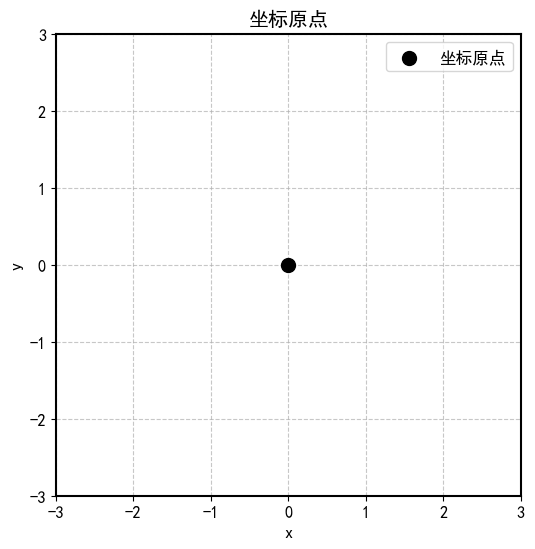

In [18]:
# 创建图形
plt.figure(figsize=(6, 6))
# 设置坐标轴范围
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.title('坐标原点')
plt.xlabel('x')
plt.ylabel('y')
# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)
# 绘制数据点
plt.scatter([0], [0], color='k', s=100, zorder=5, label='坐标原点')
plt.legend(loc="best")

### 坐标原点与拟合直线

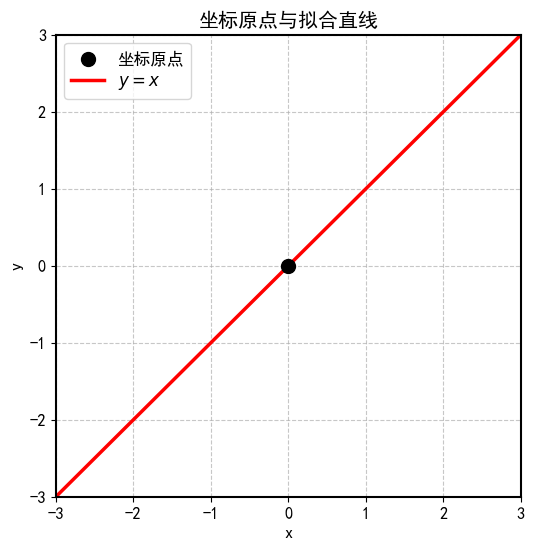

In [19]:
# 创建图形
plt.figure(figsize=(6, 6))
# 设置坐标轴范围
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.title('坐标原点与拟合直线')
plt.xlabel('x')
plt.ylabel('y')
# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)
# 绘制数据点
plt.scatter([0], [0], color='k', s=100, zorder=5, label='坐标原点')
# 生成x值范围
x = np.linspace(-3, 3, 100)
y = x 
plt.plot(x, y, 'r-', label='$y=x$')
plt.legend(loc="best")

### 坐标原点与待拟合直线

如指定直线的初始参数：$k=1,b=2$，则直线方程为$y=x+2$. 当$x=0$时，预测值$\hat{y} = 2$

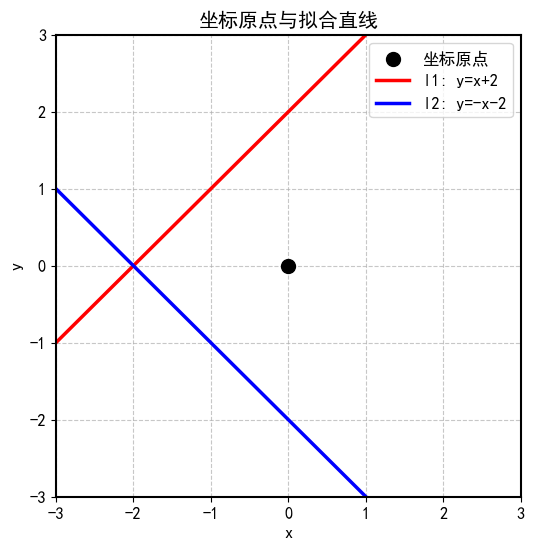

In [20]:
# 创建图形
plt.figure(figsize=(6, 6))

# 数据点
x_points = [0]
y_points = [0]

# 绘制数据点
plt.scatter(x_points, y_points, color='black', s=100, zorder=5, label='坐标原点')

# 生成x值范围
x = np.linspace(-3, 3, 100)

# 绘制第一条直线 l1: k=1, b=2
y1 = x + 2
plt.plot(x, y1, 'r-', label='l1: y=x+2')

# 绘制第二条直线 l2: k=-1, b=-2
y2 = -x - 2
plt.plot(x, y2, 'b-', label='l2: y=-x-2')

# 设置坐标轴范围
plt.xlim(-3, 3)
plt.ylim(-3, 3)

# 添加图例
plt.legend(loc='best')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和坐标轴标签
plt.title('坐标原点与拟合直线')
plt.xlabel('x')
plt.ylabel('y')

# 显示图形
plt.show()

## 损失

### 残差绝对值损失

##### 残差绝对值$L = |y-\hat{y}|$

- $\hat{y}=kx+b$

- $L=|y-\hat{y}|$

 $$L=|y-\hat{y}|=|y-kx-b|$$

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:30: SyntaxWarning: invalid escape sequence '\h'
D:\cache\Temp\ipykernel_8184\3191712069.py:11: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(y_hat, loss_abs, 'b-', label='$L = |\hat{y}|$')
D:\cache\Temp\ipykernel_8184\3191712069.py:30: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('$\hat{ŷ}$ (预测值)')


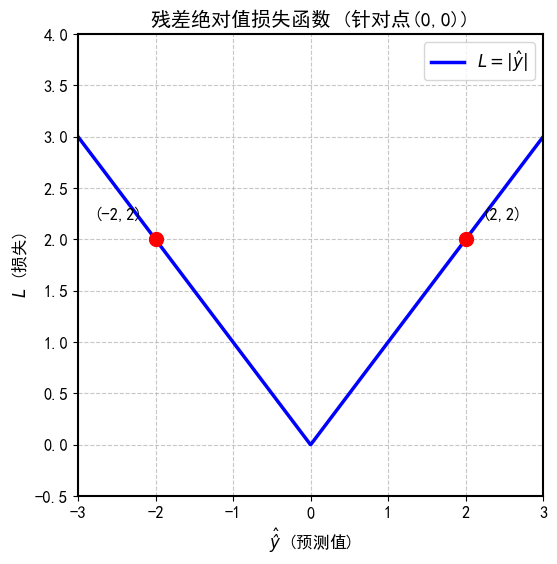

In [28]:
# 创建图形
plt.figure(figsize=(6, 6))

# 生成y_hat值范围
y_hat = np.linspace(-3, 3, 1000)

# 计算残差绝对值损失 L = |y - y_hat| = |0 - y_hat| = |y_hat|
loss_abs = np.abs(y_hat)

# 绘制损失函数曲线
plt.plot(y_hat, loss_abs, 'b-', label='$L = |\hat{y}|$')

# 标记初始损失点 (2,2) 和 (-2,2)
plt.scatter([2, -2], [2, 2], color='red', s=100, zorder=5)
plt.annotate('(2,2)', xy=(2, 2), xytext=(2.2, 2.2), fontsize=12)
plt.annotate('(-2,2)', xy=(-2, 2), xytext=(-2.8, 2.2), fontsize=12)

# 设置坐标轴范围
plt.xlim(-3, 3)
plt.ylim(-0.5, 4)

# 添加图例
plt.legend(loc='best')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和坐标轴标签
plt.title('残差绝对值损失函数 (针对点(0,0))')
plt.xlabel('$\hat{ŷ}$ (预测值)')
plt.ylabel('$L$ (损失)')
# plt.axis("equal")

# 显示图形
plt.show()

#### 残差绝对值损失-实现

In [89]:
x = torch.tensor(0.0)
y = torch.tensor(0.0)

k = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad = True)

for i in range(10):
    yh = k*x+b
    loss = torch.abs(y-yh)
    print(loss)
    loss.backward()  # 保留计算图以便后续再次反向传播

    with torch.no_grad():
        k -= k.grad*0.5
        b -= b.grad*0.5
    
    # 清零梯度，避免累积
    k.grad.zero_()
    b.grad.zero_()

tensor(3., grad_fn=<AbsBackward0>)
tensor(2.5000, grad_fn=<AbsBackward0>)
tensor(2., grad_fn=<AbsBackward0>)
tensor(1.5000, grad_fn=<AbsBackward0>)
tensor(1., grad_fn=<AbsBackward0>)
tensor(0.5000, grad_fn=<AbsBackward0>)
tensor(0., grad_fn=<AbsBackward0>)
tensor(0., grad_fn=<AbsBackward0>)
tensor(0., grad_fn=<AbsBackward0>)
tensor(0., grad_fn=<AbsBackward0>)


### 残差平方损失(0,0)

##### 残差平方$L = (y-\hat{y})^2$

- $\hat{y}=kx+b$

- $L = (y-\hat{y})^2$

 $$L=(y-\hat{y})^2=(y-kx-b)^2$$

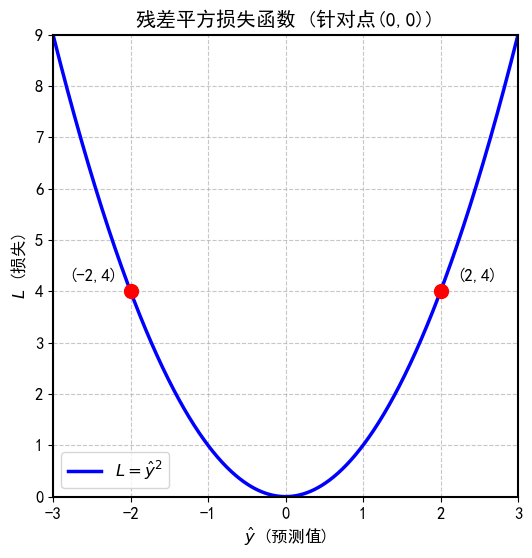

In [4]:
# 创建图形
plt.figure(figsize=(6, 6))

# 生成y_hat值范围
y_hat = np.linspace(-3, 3, 1000)

# 计算残差平方损失 L = (y - y_hat)^2 = (0 - y_hat)^2 = y_hat^2
loss_square = np.square(y_hat)

# 绘制损失函数曲线
plt.plot(y_hat, loss_square, 'b-', label='$L = \hat{y}^2$')

# 标记初始损失点 (2,4) 和 (-2,4)
plt.scatter([2, -2], [4, 4], color='red', s=100, zorder=5)
plt.annotate('(2,4)', xy=(2, 4), xytext=(2.2, 4.2), fontsize=12)
plt.annotate('(-2,4)', xy=(-2, 4), xytext=(-2.8, 4.2), fontsize=12)

# 设置坐标轴范围
plt.xlim(-3, 3)
plt.ylim(0, 9)

# 添加图例
plt.legend(loc='best')

# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 添加标题和坐标轴标签
plt.title('残差平方损失函数 (针对点(0,0))')
plt.xlabel('$\hat{y}$ (预测值)')
plt.ylabel('$L$ (损失)')

# 显示图形
plt.show()

#### 残差平方损失(0,0)-实现

In [39]:
x = torch.tensor(0.0)
y = torch.tensor(0.0)

k = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(2.0, requires_grad = True)

for i in range(10):
    yh = k*x+b
    loss = torch.square(y-yh)
    print(loss)
    loss.backward()  # 保留计算图以便后续再次反向传播

    with torch.no_grad():
        k -= k.grad*0.2
        b -= b.grad*0.2
    
    # 清零梯度，避免累积
    k.grad.zero_()
    b.grad.zero_()

tensor(9., grad_fn=<PowBackward0>)
tensor(3.2400, grad_fn=<PowBackward0>)
tensor(1.1664, grad_fn=<PowBackward0>)
tensor(0.4199, grad_fn=<PowBackward0>)
tensor(0.1512, grad_fn=<PowBackward0>)
tensor(0.0544, grad_fn=<PowBackward0>)
tensor(0.0196, grad_fn=<PowBackward0>)
tensor(0.0071, grad_fn=<PowBackward0>)
tensor(0.0025, grad_fn=<PowBackward0>)
tensor(0.0009, grad_fn=<PowBackward0>)


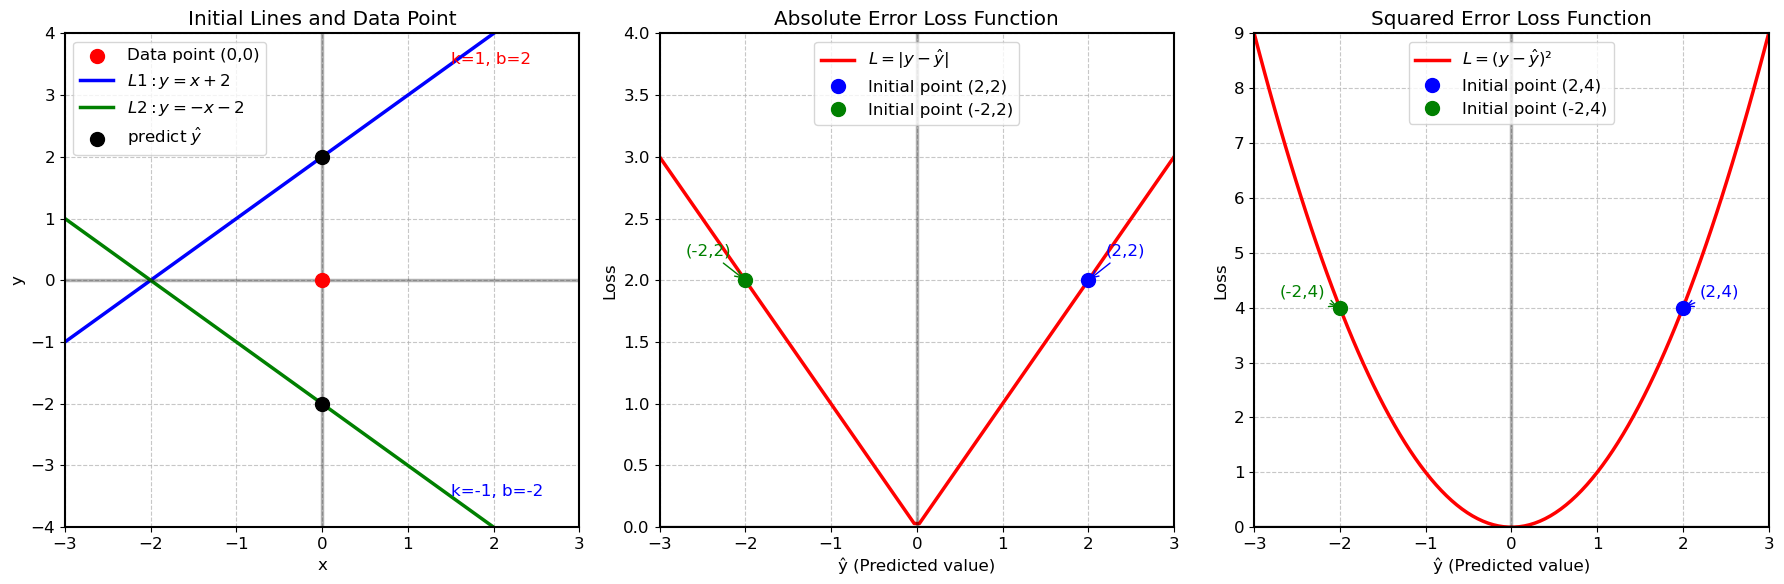

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl

# 设置全局字体和样式
# plt.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['lines.linewidth'] = 2.5
mpl.rcParams['font.size'] = 12

# 创建图像
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 第一张图：初始参数直线与点的图像
ax1 = axes[0]
x_point, y_point = 0, 0

# 绘制数据点
ax1.scatter(x_point, y_point, color='red', s=100, zorder=5, label='Data point (0,0)')

# 绘制两条直线
x_vals = np.linspace(-3, 3, 100)
y_l1 = x_vals + 2  # k=1, b=2
y_l2 = -x_vals - 2  # k=-1, b=-2

ax1.plot(x_vals, y_l1, 'b-', label='$L1: y=x+2$')
ax1.plot(x_vals, y_l2, 'g-', label='$L2: y=-x-2$')
ax1.scatter([0,0], [2,-2], color='k', s=100, zorder=5, label='predict $\hat{y}$')
# 添加标注
ax1.text(1.5, 3.5, 'k=1, b=2', color='red', fontsize=12)
ax1.text(1.5, -3.5, 'k=-1, b=-2', color='b', fontsize=12)

# 设置坐标轴范围
ax1.set_xlim(-3, 3)
ax1.set_ylim(-4, 4)

# 添加网格和图例
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax1.legend(loc='upper left')

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Initial Lines and Data Point')

# 第二张图：残差绝对值函数图像
ax2 = axes[1]
y_true = 0
y_pred = np.linspace(-3, 3, 100)
loss_abs = np.abs(y_true - y_pred)

# 绘制绝对值损失函数
ax2.plot(y_pred, loss_abs, 'r-', label='$L = |y-\hat{y}|$')

# 标记初始损失点
ax2.plot(2, 2, 'bo', markersize=10, label='Initial point (2,2)')
ax2.plot(-2, 2, 'go', markersize=10, label='Initial point (-2,2)')

# 添加标注
ax2.annotate('(2,2)', xy=(2, 2), xytext=(2.2, 2.2),
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue')
ax2.annotate('(-2,2)', xy=(-2, 2), xytext=(-2.7, 2.2),
            arrowprops=dict(arrowstyle='->', color='green'), color='green')

# 设置坐标轴范围
ax2.set_xlim(-3, 3)
ax2.set_ylim(0, 4)

# 添加网格和图例
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax2.legend(loc='upper center')

ax2.set_xlabel('ŷ (Predicted value)')
ax2.set_ylabel('Loss')
ax2.set_title('Absolute Error Loss Function')

# 第三张图：残差平方函数图像
ax3 = axes[2]
loss_square = (y_true - y_pred)**2

# 绘制平方损失函数
ax3.plot(y_pred, loss_square, 'r-', label='$L = (y-\hat{y})²$')

# 标记初始损失点
ax3.plot(2, 4, 'bo', markersize=10, label='Initial point (2,4)')
ax3.plot(-2, 4, 'go', markersize=10, label='Initial point (-2,4)')

# 添加标注
ax3.annotate('(2,4)', xy=(2, 4), xytext=(2.2, 4.2),
            arrowprops=dict(arrowstyle='->', color='blue'), color='blue')
ax3.annotate('(-2,4)', xy=(-2, 4), xytext=(-2.7, 4.2),
            arrowprops=dict(arrowstyle='->', color='green'), color='green')

# 设置坐标轴范围
ax3.set_xlim(-3, 3)
ax3.set_ylim(0, 9)

# 添加网格和图例
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax3.axvline(x=0, color='k', linestyle='-', alpha=0.3)
ax3.legend(loc='upper center')

ax3.set_xlabel('ŷ (Predicted value)')
ax3.set_ylabel('Loss')
ax3.set_title('Squared Error Loss Function')

# 调整布局
plt.tight_layout()

# 保存图像
plt.savefig('linear_regression_visualization.png', dpi=300, bbox_inches='tight')

# 显示图像
plt.show()

### 残差平方损失3D(0,0)

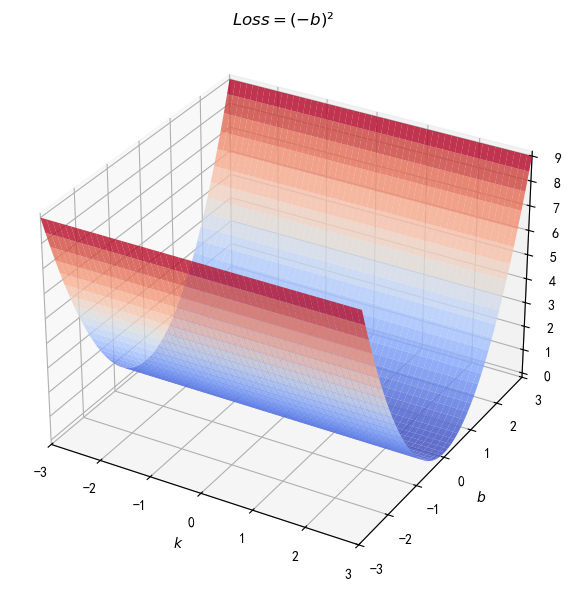

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 200)
b = np.linspace(-3, 3, 200)
K, B = np.meshgrid(k, b)

L1 = (- B)**2  # 对应点(1,0)

# 两个点的总损失函数
L_total = L1 

# 创建图形
fig = plt.figure(figsize=(6, 6))

# 两个点之和的损失函数
ax3 = fig.add_subplot(111, projection='3d')
surf3 = ax3.plot_surface(K, B, L_total, cmap=cm.coolwarm, alpha=0.8)
ax3.set_xlabel('$k$')
ax3.set_ylabel('$b$')
ax3.set_zlabel('$Loss$')
ax3.set_title('$Loss = (-b)²$')
# ax3.view_init(elev=30, azim=45)
# 设置坐标轴范围
ax3.set_xlim(-3, 3)
ax3.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

### 残差平方损失3D(1,1)

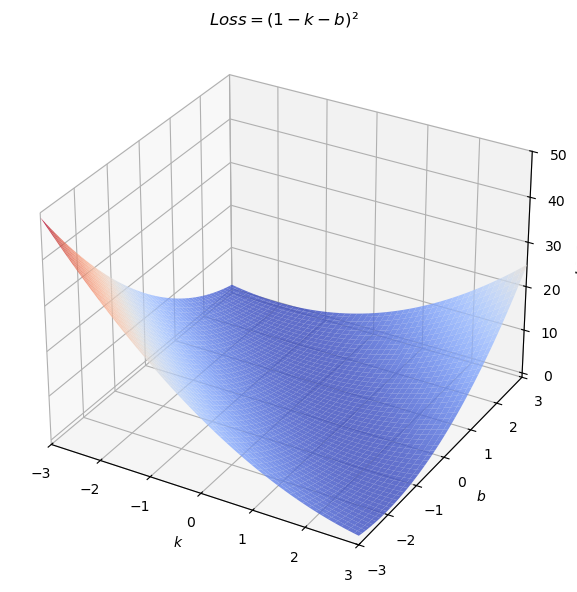

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 200)
b = np.linspace(-3, 3, 200)
K, B = np.meshgrid(k, b)

L1 = (1 - K - B)**2  # 对应点(1,1)
# L2 = (1 + K - B)**2  # 对应点(-1,1)

# 两个点的总损失函数
L_total = L1 

# 创建图形
fig = plt.figure(figsize=(6, 6))

# 两个点之和的损失函数
ax3 = fig.add_subplot(111, projection='3d')
surf3 = ax3.plot_surface(K, B, L_total, cmap=cm.coolwarm, alpha=0.8)
ax3.set_xlabel('$k$')
ax3.set_ylabel('$b$')
ax3.set_zlabel('$Loss$')
ax3.set_title('$Loss = (1-k-b)²$')
# ax3.view_init(elev=30, azim=45)
# 设置坐标轴范围
ax3.set_xlim(-3, 3)
ax3.set_ylim(-3, 3)
plt.tight_layout()
plt.show()

### 残差平方和损失3D(2 points)

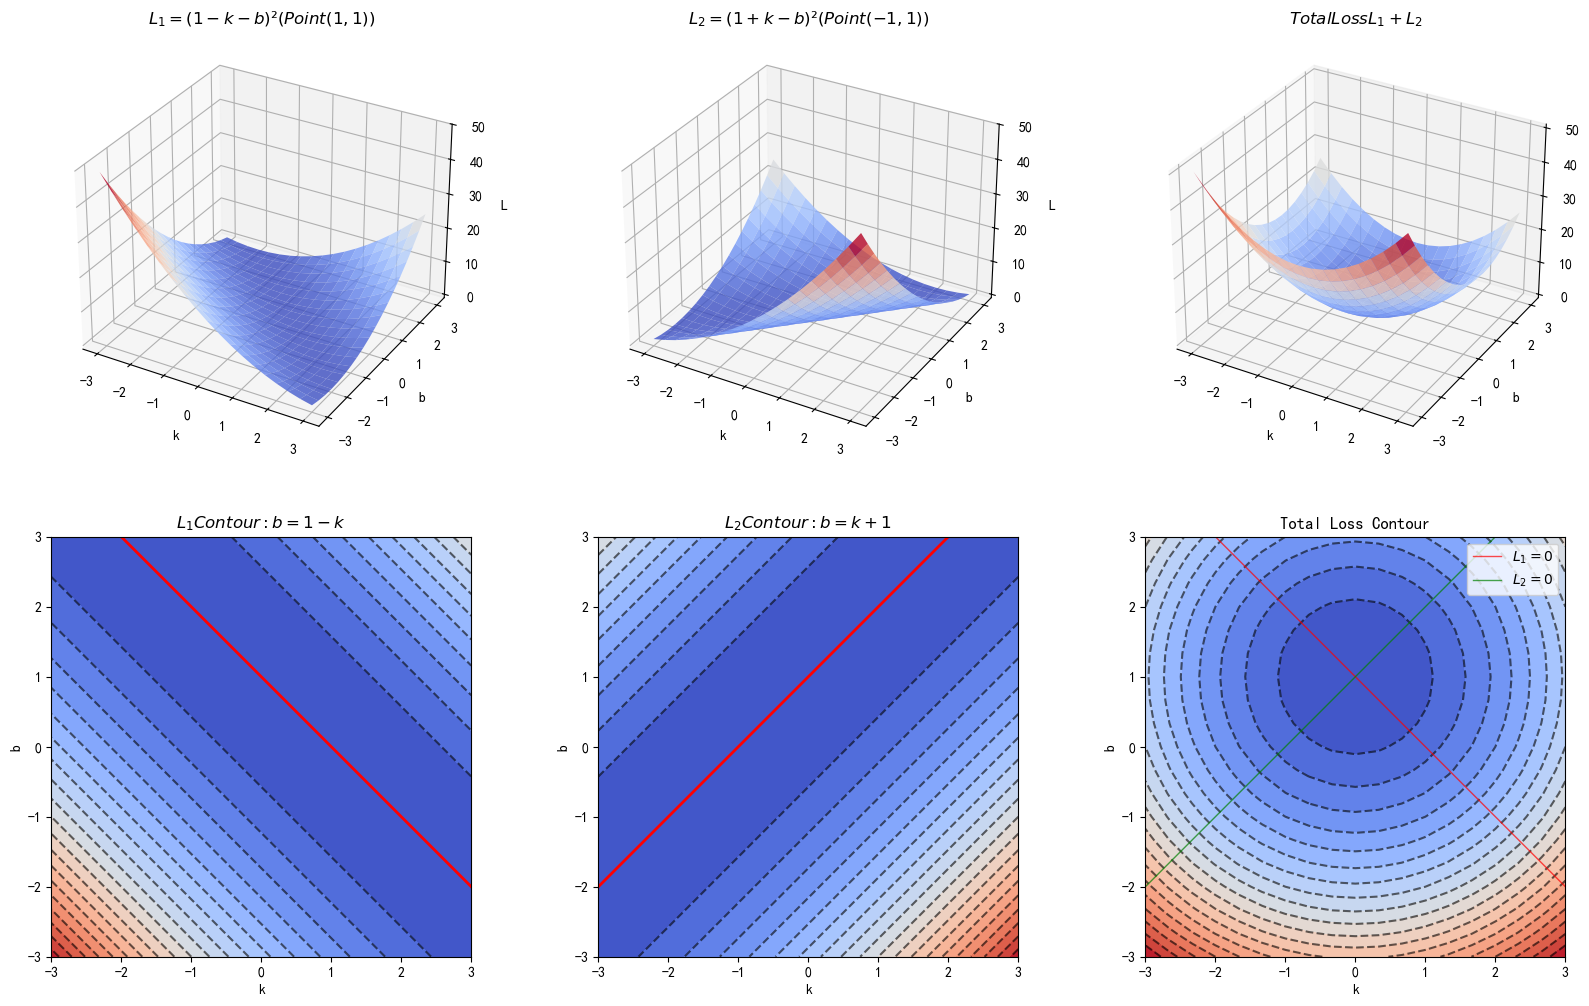

In [9]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 19)
b = np.linspace(-3, 3, 19)
K, B = np.meshgrid(k, b)

L1 = (1 - K - B)**2  # 对应点(1,1)    b = 1 - k
L2 = (1 + K - B)**2  # 对应点(-1,1)   b = -k - 1

# 四个点的总损失函数
L_total = L1 + L2 

# 创建图形
fig = plt.figure(figsize=(20, 12))

# 第一个点的损失函数
ax1 = fig.add_subplot(231, projection='3d')
surf1 = ax1.plot_surface(K, B, L1, cmap=cm.coolwarm, alpha=0.8)
ax1.set_xlabel('k')
ax1.set_ylabel('b')
ax1.set_zlabel('L')
ax1.set_title('$L_1 = (1 - k - b)² (Point (1,1))$')

# 第二个点的损失函数
ax2 = fig.add_subplot(232, projection='3d')
surf2 = ax2.plot_surface(K, B, L2, cmap=cm.coolwarm, alpha=0.8)
ax2.set_xlabel('k')
ax2.set_ylabel('b')
ax2.set_zlabel('L')
ax2.set_title('$L_2 = (1 + k - b)² (Point (-1,1))$')


# 四个点之和的损失函数
ax5 = fig.add_subplot(233, projection='3d')
surf5 = ax5.plot_surface(K, B, L_total, cmap=cm.coolwarm, alpha=0.8)
ax5.set_xlabel('k')
ax5.set_ylabel('b')
ax5.set_zlabel('L_total')
ax5.set_title('$Total Loss L_1 + L_2$')

x_line = np.linspace(-3, 3, 100)

# 第一个点的等高线
ax6 = fig.add_subplot(234)
contour1 = ax6.contour(K, B, L1, 20, colors='black', linestyles='dashed', alpha=0.6)
ax6.contourf(K, B, L1, 20, cmap=cm.coolwarm)
ax6.set_xlabel('k')
ax6.set_ylabel('b')
ax6.set_title('$L_1 Contour: b = 1 - k$')
# 绘制零损失线
ax6.plot(x_line, 1 - x_line, 'r-', linewidth=2)
ax6.set_ylim(-3, 3)
ax6.set_aspect("equal")

# 第二个点的等高线
ax7 = fig.add_subplot(235)
contour2 = ax7.contour(K, B, L2, 20, colors='black', linestyles='dashed', alpha=0.6)
ax7.contourf(K, B, L2, 20, cmap=cm.coolwarm)
ax7.set_xlabel('k')
ax7.set_ylabel('b')
ax7.set_title('$L_2 Contour: b = k + 1$')
# 绘制零损失线
ax7.plot(x_line, x_line + 1, 'r-', linewidth=2)
ax7.set_ylim(-3, 3)
ax7.set_aspect("equal")

# 总损失函数的等高线
ax10 = fig.add_subplot(2, 3, 6)
contour_total = ax10.contour(K, B, L_total, 20, colors='black', linestyles='dashed', alpha=0.6)
ax10.contourf(K, B, L_total, 20, cmap=cm.coolwarm)
ax10.set_xlabel('k')
ax10.set_ylabel('b')
ax10.set_title('Total Loss Contour')
# 绘制所有零损失线
ax10.plot(x_line, 1 - x_line, 'r-', linewidth=1, alpha=0.7, label='$L_1=0$')
ax10.plot(x_line, x_line + 1, 'g-', linewidth=1, alpha=0.7, label='$L_2=0$')
ax10.legend(loc='upper right')
ax10.set_ylim(-3, 3)
ax10.set_aspect("equal")

# plt.tight_layout()
plt.show()

### 残差平方和损失3D(4 points)

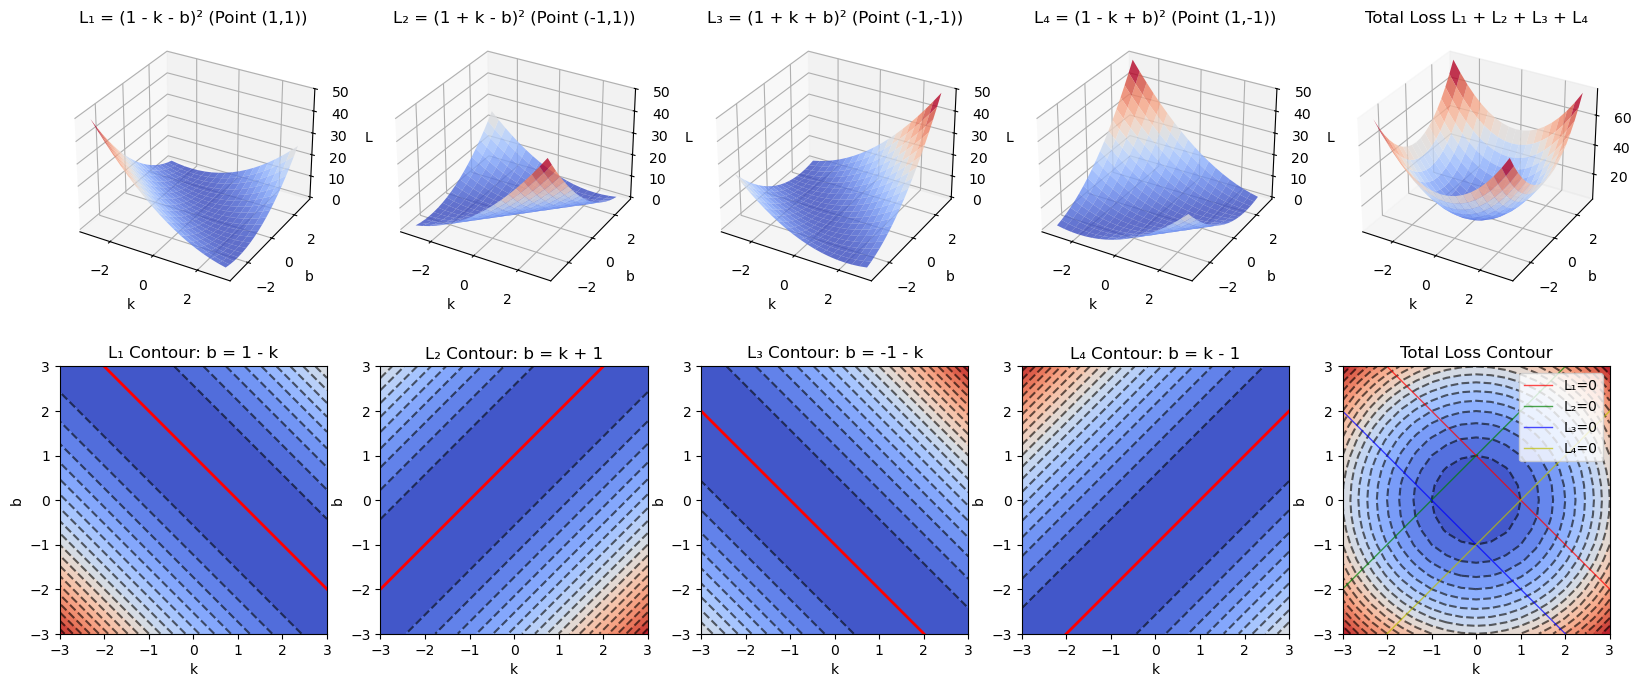

In [8]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 19)
b = np.linspace(-3, 3, 19)
K, B = np.meshgrid(k, b)

L1 = (1 - K - B)**2  # 对应点(1,1)    b = 1 - k
L2 = (1 + K - B)**2  # 对应点(-1,1)   b = -k - 1
L3 = (1 + K + B)**2  # 对应点(-1,-1)  b = -1 - k
L4 = (1 - K + B)**2  # 对应点(1,-1)   b = k - 1

# 四个点的总损失函数
L_total = L1 + L2 + L3 + L4

# 创建图形
fig = plt.figure(figsize=(20, 8))

# 第一个点的损失函数
ax1 = fig.add_subplot(251, projection='3d')
surf1 = ax1.plot_surface(K, B, L1, cmap=cm.coolwarm, alpha=0.8)
ax1.set_xlabel('k')
ax1.set_ylabel('b')
ax1.set_zlabel('L')
ax1.set_title('L₁ = (1 - k - b)² (Point (1,1))')

# 第二个点的损失函数
ax2 = fig.add_subplot(252, projection='3d')
surf2 = ax2.plot_surface(K, B, L2, cmap=cm.coolwarm, alpha=0.8)
ax2.set_xlabel('k')
ax2.set_ylabel('b')
ax2.set_zlabel('L')
ax2.set_title('L₂ = (1 + k - b)² (Point (-1,1))')

# 第三个点的损失函数
ax3 = fig.add_subplot(253, projection='3d')
surf3 = ax3.plot_surface(K, B, L3, cmap=cm.coolwarm, alpha=0.8)
ax3.set_xlabel('k')
ax3.set_ylabel('b')
ax3.set_zlabel('L')
ax3.set_title('L₃ = (1 + k + b)² (Point (-1,-1))')

# 第四个点的损失函数
ax4 = fig.add_subplot(254, projection='3d')
surf4 = ax4.plot_surface(K, B, L4, cmap=cm.coolwarm, alpha=0.8)
ax4.set_xlabel('k')
ax4.set_ylabel('b')
ax4.set_zlabel('L')
ax4.set_title('L₄ = (1 - k + b)² (Point (1,-1))')

# 四个点之和的损失函数
ax5 = fig.add_subplot(255, projection='3d')
surf5 = ax5.plot_surface(K, B, L_total, cmap=cm.coolwarm, alpha=0.8)
ax5.set_xlabel('k')
ax5.set_ylabel('b')
ax5.set_zlabel('L_total')
ax5.set_title('Total Loss L₁ + L₂ + L₃ + L₄')

x_line = np.linspace(-3, 3, 100)

# 第一个点的等高线
ax6 = fig.add_subplot(256)
contour1 = ax6.contour(K, B, L1, 20, colors='black', linestyles='dashed', alpha=0.6)
ax6.contourf(K, B, L1, 20, cmap=cm.coolwarm)
ax6.set_xlabel('k')
ax6.set_ylabel('b')
ax6.set_title('L₁ Contour: b = 1 - k')
# 绘制零损失线
ax6.plot(x_line, 1 - x_line, 'r-', linewidth=2)
ax6.set_ylim(-3, 3)
ax6.set_aspect("equal")

# 第二个点的等高线
ax7 = fig.add_subplot(257)
contour2 = ax7.contour(K, B, L2, 20, colors='black', linestyles='dashed', alpha=0.6)
ax7.contourf(K, B, L2, 20, cmap=cm.coolwarm)
ax7.set_xlabel('k')
ax7.set_ylabel('b')
ax7.set_title('L₂ Contour: b = k + 1')
# 绘制零损失线
ax7.plot(x_line, x_line + 1, 'r-', linewidth=2)
ax7.set_ylim(-3, 3)
ax7.set_aspect("equal")

# 第三个点的等高线
ax8 = fig.add_subplot(258)
contour3 = ax8.contour(K, B, L3, 20, colors='black', linestyles='dashed', alpha=0.6)
ax8.contourf(K, B, L3, 20, cmap=cm.coolwarm)
ax8.set_xlabel('k')
ax8.set_ylabel('b')
ax8.set_title('L₃ Contour: b = -1 - k')
# 绘制零损失线
ax8.plot(x_line, -1 - x_line, 'r-', linewidth=2)
ax8.set_ylim(-3, 3)
ax8.set_aspect("equal")

# 第四个点的等高线
ax9 = fig.add_subplot(259)
contour4 = ax9.contour(K, B, L4, 20, colors='black', linestyles='dashed', alpha=0.6)
ax9.contourf(K, B, L4, 20, cmap=cm.coolwarm)
ax9.set_xlabel('k')
ax9.set_ylabel('b')
ax9.set_title('L₄ Contour: b = k - 1')
# 绘制零损失线
ax9.plot(x_line, x_line - 1, 'r-', linewidth=2)
ax9.set_ylim(-3, 3)
ax9.set_aspect("equal")

# 总损失函数的等高线
ax10 = fig.add_subplot(2, 5, 10)
contour_total = ax10.contour(K, B, L_total, 20, colors='black', linestyles='dashed', alpha=0.6)
ax10.contourf(K, B, L_total, 20, cmap=cm.coolwarm)
ax10.set_xlabel('k')
ax10.set_ylabel('b')
ax10.set_title('Total Loss Contour')
# 绘制所有零损失线
ax10.plot(x_line, 1 - x_line, 'r-', linewidth=1, alpha=0.7, label='L₁=0')
ax10.plot(x_line, x_line + 1, 'g-', linewidth=1, alpha=0.7, label='L₂=0')
ax10.plot(x_line, -1 - x_line, 'b-', linewidth=1, alpha=0.7, label='L₃=0')
ax10.plot(x_line, x_line - 1, 'y-', linewidth=1, alpha=0.7, label='L₄=0')
ax10.legend(loc='upper right')
ax10.set_ylim(-3, 3)
ax10.set_aspect("equal")

# plt.tight_layout()
plt.show()

##### 残差平方和$L = \sum_{i=1}^{i=n}(y-\hat{y})^2$

自变量为$\hat{y}$，多个凸函数相加仍然是凸函数。

### 均方残差损失3D(4 points)

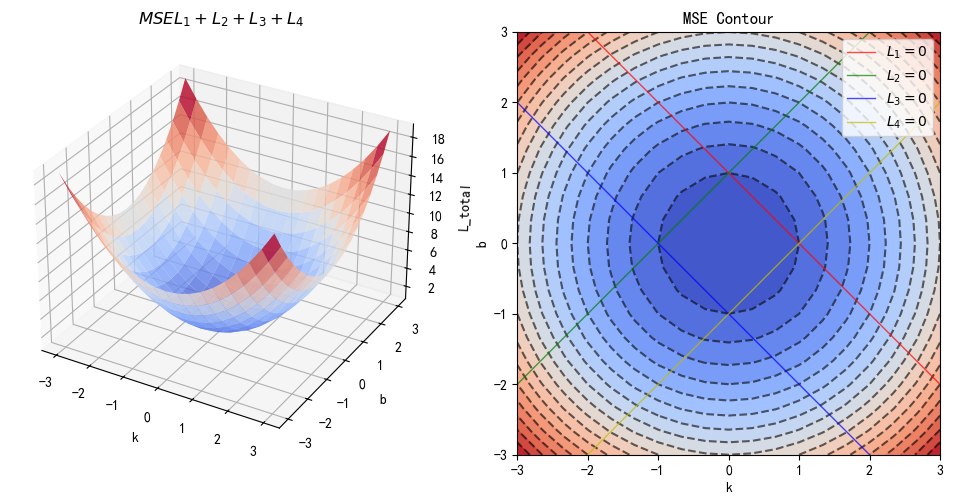

In [6]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 19)
b = np.linspace(-3, 3, 19)
K, B = np.meshgrid(k, b)

L1 = (1 - K - B)**2  # 对应点(1,1)    b = 1 - k
L2 = (1 + K - B)**2  # 对应点(-1,1)   b = -k - 1
L3 = (1 + K + B)**2  # 对应点(-1,-1)  b = -1 - k
L4 = (1 - K + B)**2  # 对应点(1,-1)   b = k - 1

# 四个点的总损失函数
L_total = (L1 + L2 + L3 + L4)/4

# 创建图形
fig = plt.figure(figsize=(12, 8))

# 四个点之和的损失函数
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(K, B, L_total, cmap=cm.coolwarm, alpha=0.8)
ax1.set_xlabel('k')
ax1.set_ylabel('b')
ax1.set_zlabel('L_total')
ax1.set_title('$MSE L_1 + L_2 + L_3 + L_4$')

x_line = np.linspace(-3, 3, 100)

# 总损失函数的等高线
ax4 = fig.add_subplot(122)
contour_total = ax4.contour(K, B, L_total, 20, colors='black', linestyles='dashed', alpha=0.6)
ax4.contourf(K, B, L_total, 20, cmap=cm.coolwarm)
ax4.set_xlabel('k')
ax4.set_ylabel('b')
ax4.set_title('MSE Contour')
# 绘制所有零损失线
ax4.plot(x_line, 1 - x_line, 'r-', linewidth=1, alpha=0.7, label='$L_1=0$')
ax4.plot(x_line, x_line + 1, 'g-', linewidth=1, alpha=0.7, label='$L_2=0$')
ax4.plot(x_line, -1 - x_line, 'b-', linewidth=1, alpha=0.7, label='$L_3=0$')
ax4.plot(x_line, x_line - 1, 'y-', linewidth=1, alpha=0.7, label='$L_4=0$')
ax4.legend(loc='upper right')
ax4.set_ylim(-3, 3)
ax4.set_aspect("equal")

# plt.tight_layout()
plt.show()

##### 均方误差$L = \frac{1}{n}\sum_{i=1}^{i=n}(y-\hat{y})^2$

函数值做平均，不会影响参数$k,b$的位置

## 梯度下降


### 梯度下降法

#### **核心定义**

梯度下降法是一种用于**寻找函数最小值**的通用优化算法。它通过迭代的方式，一步步调整函数的参数，以逼近最小值点。

#### **详细解释**

1.  **目的**：它是机器学习中**训练模型**的核心算法，用于找到使“损失函数”（如均方误差）最小的模型参数（如线性回归中的 `w` 和 `b`）。
2.  **核心思想**：
    *   **梯度**：函数在某一点的方向导数，指向函数值**上升最快**的方向。
    *   **下降**：既然梯度指向上升最快的方向，那么它的反方向就是函数值**下降最快**的方向。
    *   因此，我们沿着梯度反方向小步前进，就能最快地接近函数的最小值。

---

#### **过程**

**1. 初始化**

随机选择一组起始参数（如随机设置 $k$ 和 $b$ 的值）。

---

##### **2. 计算梯度(链式求导)**

计算当前参数下的损失函数梯度。对于线性回归模型 $\hat{y}=kx+b$ 和损失函数 $L = (y-\hat{y})^2$：

- $\frac{\partial L}{\partial \hat{y}} = -2(y-\hat{y})$， $\frac{\partial \hat{y}}{\partial k} = x$，$\frac{\partial \hat{y}}{\partial b} = 1$
- $\frac{\partial L}{\partial k} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial k} = -2(y-\hat{y}) \cdot x$
- $\frac{\partial L}{\partial b} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial b} = -2(y-\hat{y}) \cdot 1 = -2(y-\hat{y})$

---

##### **3. 更新参数**

沿着梯度反方向，以一**学习率** 所定义的步长，更新参数。

`新参数 = 旧参数 - 学习率 * 梯度`

- $k_{new} = k_{old} - \alpha \cdot \frac{\partial L}{\partial k} = k_{old} - \alpha \cdot (-2(y-\hat{y}) \cdot x) = k_{old} + 2\alpha(y-\hat{y})x$

- $b_{new} = b_{old} - \alpha \cdot \frac{\partial L}{\partial b} = b_{old} - \alpha \cdot (-2(y-\hat{y})) = b_{old} + 2\alpha(y-\hat{y})$

其中 $\alpha$ 是学习率，控制每次参数更新的步长。

##### **4. 迭代**

重复“计算梯度”和“更新参数”两步，直到梯度变得非常小（收敛）或达到预设的迭代次数。

---

**关键概念：**

*   **学习率**：每一步更新的幅度。太小会导致收敛过慢，太大会导致无法收敛甚至发散。
*   **损失函数**：衡量模型预测好坏的函数，梯度下降的目标就是最小化它。

**简单比喻：**
想象你蒙着眼在一个崎岖的山坡上，想要以最快的速度下到山谷（最小值点）。你每走一步，就用脚感受一下四周最陡的下坡方向（计算梯度），然后朝着那个方向迈出一小步（学习率）。重复这个过程，你最终就能到达山谷底部。


### 随机梯度下降(SGD)

初始参数: k = -3.00, b = -3.00
使用点(1.0, 1.0)后: k = -1.60, b = -1.60, 损失 = 49.00
使用点(-1.0, 1.0)后: k = -1.80, b = -1.40, 损失 = 1.00
使用点(-1.0, -1.0)后: k = -1.52, b = -1.68, 损失 = 1.96
使用点(1.0, 1.0)后: k = -0.68, b = -0.84, 损失 = 17.64
使用点(-1.0, 1.0)后: k = -0.91, b = -0.61, 损失 = 1.35
使用点(-1.0, -1.0)后: k = -0.65, b = -0.87, 损失 = 1.70
使用点(1.0, 1.0)后: k = -0.15, b = -0.36, 损失 = 6.35
使用点(-1.0, 1.0)后: k = -0.39, b = -0.12, 损失 = 1.48
使用点(-1.0, -1.0)后: k = -0.14, b = -0.38, 损失 = 1.61


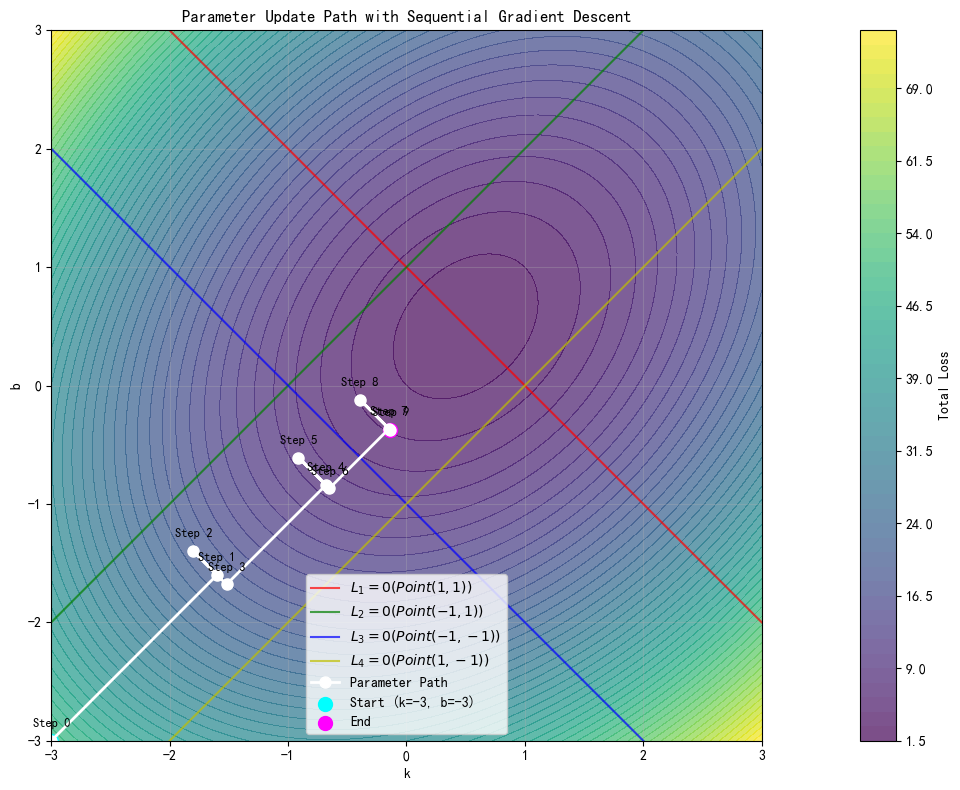


最终参数: k = -0.1368, b = -0.3752
最终总损失: 4.5060


In [9]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以确保结果可重现
torch.manual_seed(42)

# 定义四个数据点
points = [
    torch.tensor([1.0, 1.0]),  # (x, y) = (1, 1)
    torch.tensor([-1.0, 1.0]), # (x, y) = (-1, 1)
    torch.tensor([-1.0, -1.0]),# (x, y) = (-1, -1)
    # torch.tensor([1.0, -1.0])  # (x, y) = (1, -1)
]

# 初始化参数
k = torch.tensor([-3.0], requires_grad=True)
b = torch.tensor([-3.0], requires_grad=True)

# 学习率
learning_rate = 0.1

# 存储参数更新路径
path = [(k.item(), b.item())]

# 创建优化器，只优化k和b
optimizer = optim.SGD([k, b], lr=learning_rate)

print("初始参数: k = {:.2f}, b = {:.2f}".format(k.item(), b.item()))

for j in range(3):
    # 进行四次顺序梯度下降
    for i, point in enumerate(points):
        # 清零梯度
        optimizer.zero_grad()
        
        # 计算预测值
        x, y_true = point
        y_pred = k * x + b
        
        # 计算损失
        loss = (y_pred - y_true) ** 2
        
        # 反向传播
        loss.backward()
        
        # 更新参数
        optimizer.step()
        
        # 记录参数
        path.append((k.item(), b.item()))
        
        print("使用点({}, {})后: k = {:.2f}, b = {:.2f}, 损失 = {:.2f}".format(
            x.item(), y_true.item(), k.item(), b.item(), loss.item()))

# 将路径转换为numpy数组以便绘图
path = np.array(path)

# 绘制参数更新路径
plt.figure(figsize=(20, 8))

# 绘制等高线
k_vals = np.linspace(-3, 3, 100)
b_vals = np.linspace(-3, 3, 100)
K, B = np.meshgrid(k_vals, b_vals)

# 计算总损失
L_total = np.zeros_like(K)
for point in points:
    x, y_true = point
    L_total += (K * x.item() + B - y_true.item()) ** 2

# 绘制等高线图
plt.contourf(K, B, L_total, 50, cmap='viridis', alpha=0.7)
plt.colorbar(label='Total Loss')

# 绘制零损失线
x_line = np.linspace(-3, 3, 100)
plt.plot(x_line, 1 - x_line, 'r-', label='$L_1=0 (Point (1,1))$', alpha=0.7)
plt.plot(x_line, 1 + x_line, 'g-', label='$L_2=0 (Point (-1,1))$', alpha=0.7)
plt.plot(x_line, -1 - x_line, 'b-', label='$L_3=0 (Point (-1,-1))$', alpha=0.7)
plt.plot(x_line, x_line - 1, 'y-', label='$L_4=0 (Point (1,-1))$', alpha=0.7)

# 绘制参数更新路径
plt.plot(path[:, 0], path[:, 1], 'wo-', markersize=8, linewidth=2, label='Parameter Path')
plt.scatter(path[0, 0], path[0, 1], c='cyan', s=100, label='Start (k=-3, b=-3)')
plt.scatter(path[-1, 0], path[-1, 1], c='magenta', s=100, label='End')

# 标记每一步
for i, (k_val, b_val) in enumerate(path):
    plt.annotate(f'Step {i}', (k_val, b_val), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9)

# 设置图形属性
plt.xlabel('k')
plt.ylabel('b')
plt.title('Parameter Update Path with Sequential Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

# 打印最终结果
print("\n最终参数: k = {:.4f}, b = {:.4f}".format(k.item(), b.item()))
print("最终总损失: {:.4f}".format(L_total[np.abs(b_vals - b.item()).argmin(), 
                                np.abs(k_vals - k.item()).argmin()]))

### 批量梯度下降(BGD)

初始参数: k = -3.00, b = -3.00
Epoch 1: k = -2.53, b = -2.53, 总损失 = 17.00
Epoch 2: k = -2.13, b = -2.13, 总损失 = 12.93
Epoch 3: k = -1.78, b = -1.78, 总损失 = 9.88
Epoch 4: k = -1.47, b = -1.47, 总损失 = 7.59
Epoch 5: k = -1.21, b = -1.21, 总损失 = 5.87
Epoch 6: k = -0.98, b = -0.98, 总损失 = 4.57
Epoch 7: k = -0.79, b = -0.79, 总损失 = 3.60
Epoch 8: k = -0.61, b = -0.61, 总损失 = 2.87
Epoch 9: k = -0.47, b = -0.47, 总损失 = 2.32
Epoch 10: k = -0.34, b = -0.34, 总损失 = 1.91
Epoch 11: k = -0.23, b = -0.23, 总损失 = 1.60
Epoch 12: k = -0.13, b = -0.13, 总损失 = 1.37
Epoch 13: k = -0.04, b = -0.04, 总损失 = 1.19
Epoch 14: k = 0.03, b = 0.03, 总损失 = 1.06
Epoch 15: k = 0.09, b = 0.09, 总损失 = 0.96
Epoch 16: k = 0.15, b = 0.15, 总损失 = 0.89
Epoch 17: k = 0.19, b = 0.19, 总损失 = 0.83


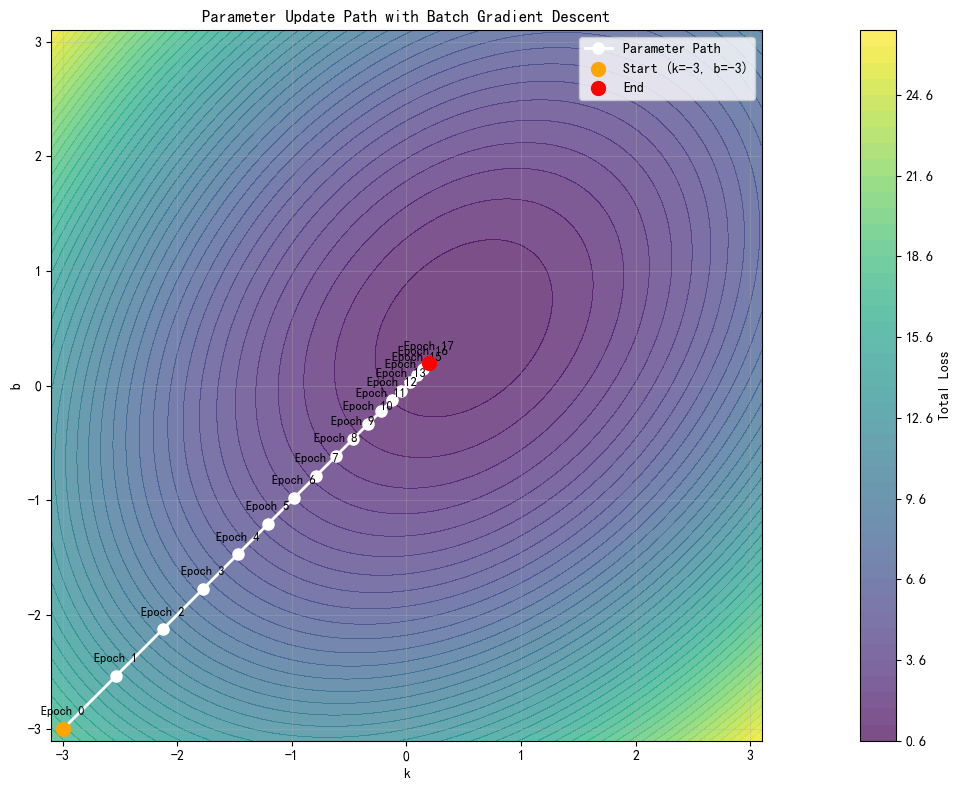


最终参数: k = 0.1927, b = 0.1927
最终总损失: 0.7718


In [10]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以确保结果可重现
torch.manual_seed(42)

# 定义四个数据点
points = torch.tensor([
    [1.0, 1.0],    # (x, y) = (1, 1)
    [-1.0, 1.0],   # (x, y) = (-1, 1)
    [-1.0, -1.0],  # (x, y) = (-1, -1)
    # [1.0, -1.0]    # (x, y) = (1, -1)
])

# 初始化参数
k = torch.tensor([-3.0], requires_grad=True)
b = torch.tensor([-3.0], requires_grad=True)

# 学习率
learning_rate = 0.1

# 存储参数更新路径
path = [(k.item(), b.item())]

# 创建优化器，只优化k和b
optimizer = optim.SGD([k, b], lr=learning_rate)

print("初始参数: k = {:.2f}, b = {:.2f}".format(k.item(), b.item()))

# 批量梯度下降
for epoch in range(17):
    # 清零梯度
    optimizer.zero_grad()
    
    # 计算所有点的预测值
    x_data = points[:, 0]
    y_true = points[:, 1]
    y_pred = k * x_data + b
    
    # 计算总损失
    loss = torch.sum((y_pred - y_true) ** 2)/3
    
    # 反向传播
    loss.backward()
    
    # 更新参数
    optimizer.step()
    
    # 记录参数
    path.append((k.item(), b.item()))
    
    print("Epoch {}: k = {:.2f}, b = {:.2f}, 总损失 = {:.2f}".format(
        epoch+1, k.item(), b.item(), loss.item()))

# 将路径转换为numpy数组以便绘图
path = np.array(path)

# 绘制参数更新路径
plt.figure(figsize=(20, 8))

# 绘制等高线
k_vals = np.linspace(-3.1, 3.1, 100)
b_vals = np.linspace(-3.1, 3.1, 100)
K, B = np.meshgrid(k_vals, b_vals)

# 计算总损失
L_total = np.zeros_like(K)
for point in points:
    x, y_true = point
    L_total += (K * x.item() + B - y_true.item()) ** 2
L_total = L_total/3

# 绘制等高线图
plt.contourf(K, B, L_total, 50, cmap='viridis', alpha=0.7)
plt.colorbar(label='Total Loss')

# 绘制参数更新路径
plt.plot(path[:, 0], path[:, 1], 'wo-', markersize=8, linewidth=2, label='Parameter Path')
plt.scatter(path[0, 0], path[0, 1], c='orange', s=100, label='Start (k=-3, b=-3)', zorder=10)
plt.scatter(path[-1, 0], path[-1, 1], c='red', s=100, label='End', zorder=10)

# 标记每一步
for i, (k_val, b_val) in enumerate(path):
    plt.annotate(f'Epoch {i}', (k_val, b_val), textcoords="offset points", 
                 xytext=(0,10), ha='center', fontsize=9)

# 设置图形属性
plt.xlabel('k')
plt.ylabel('b')
plt.title('Parameter Update Path with Batch Gradient Descent')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-3.1, 3.1)
plt.ylim(-3.1, 3.1)
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

# 打印最终结果
print("\n最终参数: k = {:.4f}, b = {:.4f}".format(k.item(), b.item()))
print("最终总损失: {:.4f}".format(L_total[np.abs(b_vals - b.item()).argmin(), 
                                np.abs(k_vals - k.item()).argmin()]))

### 小批量梯度下降(mini-batch GD)

初始参数: k = -3.00, b = -3.00
Epoch 1, Batch 1: k = -3.00, b = -3.00, 批次损失 = 1.00
Epoch 1, Batch 2: k = -2.30, b = -2.30, 批次损失 = 24.50
Epoch 1 平均损失: 12.75
Epoch 2, Batch 1: k = -2.30, b = -2.30, 批次损失 = 1.00
Epoch 2, Batch 2: k = -1.74, b = -1.74, 批次损失 = 15.68
Epoch 2 平均损失: 8.34
Epoch 3, Batch 1: k = -1.19, b = -1.39, 批次损失 = 10.54
Epoch 3, Batch 2: k = -1.31, b = -1.27, 批次损失 = 0.72
Epoch 3 平均损失: 5.63
Epoch 4, Batch 1: k = -1.05, b = -0.82, 批次损失 = 6.88
Epoch 4, Batch 2: k = -0.93, b = -0.94, 批次损失 = 0.76
Epoch 4 平均损失: 3.82
Epoch 5, Batch 1: k = -0.54, b = -0.75, 批次损失 = 4.60
Epoch 5, Batch 2: k = -0.66, b = -0.63, 批次损失 = 0.73
Epoch 5 平均损失: 2.67
Epoch 6, Batch 1: k = -0.33, b = -0.51, 批次损失 = 3.16
Epoch 6, Batch 2: k = -0.45, b = -0.39, 批次损失 = 0.69
Epoch 6 平均损失: 1.93
Epoch 7, Batch 1: k = -0.16, b = -0.31, 批次损失 = 2.25
Epoch 7, Batch 2: k = -0.27, b = -0.19, 批次损失 = 0.66
Epoch 7 平均损失: 1.45
Epoch 8, Batch 1: k = -0.02, b = -0.16, 批次损失 = 1.66
Epoch 8, Batch 2: k = -0.13, b = -0.04, 批次损失 = 0.65
Epoc

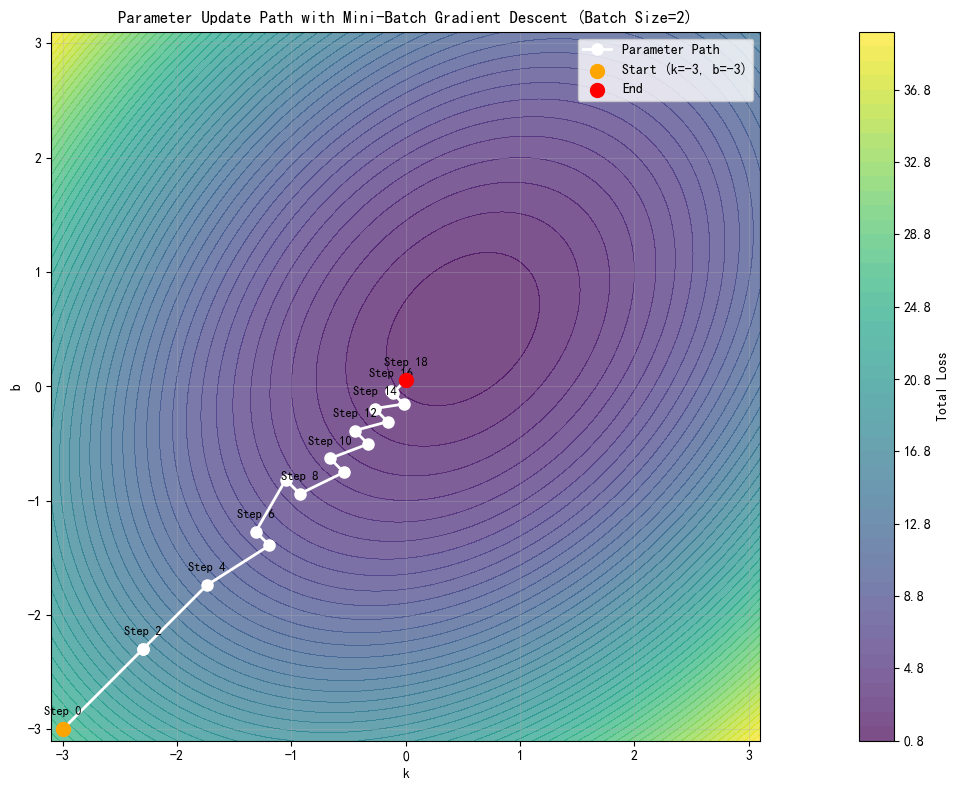


最终参数: k = 0.0032, b = 0.0573
最终总损失: 1.4393


In [11]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# 设置随机种子以确保结果可重现
torch.manual_seed(42)

# 定义四个数据点
points = torch.tensor([
    [1.0, 1.0],    # (x, y) = (1, 1)
    [-1.0, 1.0],   # (x, y) = (-1, 1)
    [-1.0, -1.0],  # (x, y) = (-1, -1)
    # [1.0, -1.0]    # (x, y) = (1, -1)
])

# 创建数据集和数据加载器，批次大小为2
dataset = TensorDataset(points[:, 0], points[:, 1])
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# 初始化参数
k = torch.tensor([-3.0], requires_grad=True)
b = torch.tensor([-3.0], requires_grad=True)

# 学习率
learning_rate = 0.1

# 存储参数更新路径
path = [(k.item(), b.item())]

# 创建优化器，只优化k和b
optimizer = optim.SGD([k, b], lr=learning_rate)

print("初始参数: k = {:.2f}, b = {:.2f}".format(k.item(), b.item()))

# 小批量梯度下降
num_epochs = 9
for epoch in range(num_epochs):
    epoch_loss = 0.0
    batch_count = 0
    
    for batch_x, batch_y in dataloader:
        # 清零梯度
        optimizer.zero_grad()
        
        # 计算当前批次的预测值
        y_pred = k * batch_x + b
        
        # 计算当前批次的损失
        loss = torch.sum((y_pred - batch_y) ** 2)/2
        
        # 反向传播
        loss.backward()
        
        # 更新参数
        optimizer.step()
        
        # 记录参数
        path.append((k.item(), b.item()))
        
        epoch_loss += loss.item()
        batch_count += 1
        
        print("Epoch {}, Batch {}: k = {:.2f}, b = {:.2f}, 批次损失 = {:.2f}".format(
            epoch+1, batch_count, k.item(), b.item(), loss.item()))
    
    print("Epoch {} 平均损失: {:.2f}".format(epoch+1, epoch_loss / batch_count))

# 将路径转换为numpy数组以便绘图
path = np.array(path)

# 绘制参数更新路径
plt.figure(figsize=(20, 8))

# 绘制等高线
k_vals = np.linspace(-3.1, 3.1, 100)
b_vals = np.linspace(-3.1, 3.1, 100)
K, B = np.meshgrid(k_vals, b_vals)

# 计算总损失
L_total = np.zeros_like(K)
for point in points:
    x, y_true = point
    L_total += (K * x.item() + B - y_true.item()) ** 2
L_total = L_total/2

# 绘制等高线图
plt.contourf(K, B, L_total, 50, cmap='viridis', alpha=0.7)
plt.colorbar(label='Total Loss')

# 绘制参数更新路径
plt.plot(path[:, 0], path[:, 1], 'wo-', markersize=8, linewidth=2, label='Parameter Path')
plt.scatter(path[0, 0], path[0, 1], c='orange', s=100, label='Start (k=-3, b=-3)', zorder=10)
plt.scatter(path[-1, 0], path[-1, 1], c='red', s=100, label='End', zorder=10)

# 标记关键步骤
for i, (k_val, b_val) in enumerate(path):
    if i == 0 or i == len(path)-1 or i % 2 == 0:  # 只标记起始点、结束点和每两个批次
        plt.annotate(f'Step {i}', (k_val, b_val), textcoords="offset points", 
                     xytext=(0,10), ha='center', fontsize=9)

# 设置图形属性
plt.xlabel('k')
plt.ylabel('b')
plt.title('Parameter Update Path with Mini-Batch Gradient Descent (Batch Size=2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-3.1, 3.1)
plt.ylim(-3.1, 3.1)
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

# 打印最终结果
print("\n最终参数: k = {:.4f}, b = {:.4f}".format(k.item(), b.item()))
print("最终总损失: {:.4f}".format(L_total[np.abs(b_vals - b.item()).argmin(), 
                                np.abs(k_vals - k.item()).argmin()]))

## 正则化

### 范数

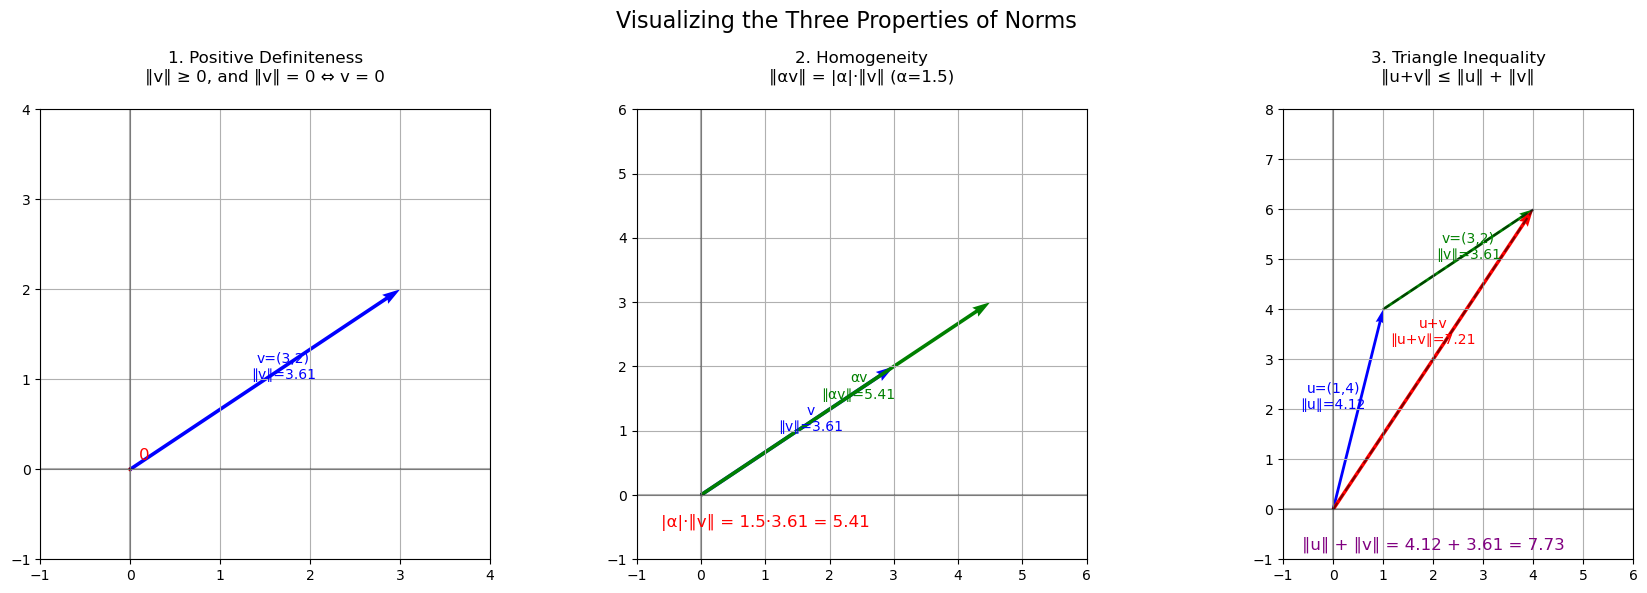

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc

# 设置图形
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Visualizing the Three Properties of Norms', fontsize=16, y=0.98)

# 定义一些示例向量
v = np.array([3, 2])
u = np.array([1, 4])
alpha = 1.5

# 1. 正定性可视化
ax1 = axes[0]
ax1.set_title('1. Positive Definiteness\n∥v∥ ≥ 0, and ∥v∥ = 0 ⇔ v = 0', pad=20)

# 绘制零向量
ax1.quiver(0, 0, 0, 0, angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
ax1.text(0.1, 0.1, '0', fontsize=12, color='red')

# 绘制非零向量
ax1.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.008)
ax1.text(v[0]/2+0.2, v[1]/2, f'v=({v[0]},{v[1]})\n∥v∥={np.linalg.norm(v):.2f}', 
         fontsize=10, color='blue', ha='center')

ax1.set_xlim(-1, 4)
ax1.set_ylim(-1, 4)
ax1.grid(True)
ax1.set_aspect('equal')
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# 2. 齐次性可视化
ax2 = axes[1]
ax2.set_title(f'2. Homogeneity\n∥αv∥ = |α|·∥v∥ (α={alpha})', pad=20)

# 绘制原向量
ax2.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.008)
ax2.text(v[0]/2+0.2, v[1]/2, f'v\n∥v∥={np.linalg.norm(v):.2f}', 
         fontsize=10, color='blue', ha='center')

# 绘制缩放后的向量
scaled_v = alpha * v
ax2.quiver(0, 0, scaled_v[0], scaled_v[1], angles='xy', scale_units='xy', scale=1, 
           color='green', width=0.008)
ax2.text(scaled_v[0]/2+0.2, scaled_v[1]/2, f'αv\n∥αv∥={np.linalg.norm(scaled_v):.2f}', 
         fontsize=10, color='green', ha='center')

# 添加说明文本
ax2.text(1, -0.5, f'|α|·∥v∥ = {abs(alpha)}·{np.linalg.norm(v):.2f} = {abs(alpha)*np.linalg.norm(v):.2f}', 
         fontsize=12, color='red', ha='center')

ax2.set_xlim(-1, 6)
ax2.set_ylim(-1, 6)
ax2.grid(True)
ax2.set_aspect('equal')
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3)

# 3. 三角不等式可视化
ax3 = axes[2]
ax3.set_title('3. Triangle Inequality\n∥u+v∥ ≤ ∥u∥ + ∥v∥', pad=20)

# 绘制向量 u
ax3.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.008)
ax3.text(u[0]/2-0.5, u[1]/2, f'u=({u[0]},{u[1]})\n∥u∥={np.linalg.norm(u):.2f}', 
         fontsize=10, color='blue', ha='center')

# 绘制向量 v
ax3.quiver(u[0], u[1], v[0], v[1], angles='xy', scale_units='xy', scale=1, color='green', width=0.008)
ax3.text(u[0]+v[0]/2+0.2, u[1]+v[1]/2, f'v=({v[0]},{v[1]})\n∥v∥={np.linalg.norm(v):.2f}', 
         fontsize=10, color='green', ha='center')

# 绘制向量 u+v
sum_uv = u + v
ax3.quiver(0, 0, sum_uv[0], sum_uv[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)
ax3.text(sum_uv[0]/2, sum_uv[1]/2+0.3, f'u+v\n∥u+v∥={np.linalg.norm(sum_uv):.2f}', 
         fontsize=10, color='red', ha='center')

# 添加说明文本
ax3.text(2, -0.8, f'∥u∥ + ∥v∥ = {np.linalg.norm(u):.2f} + {np.linalg.norm(v):.2f} = {np.linalg.norm(u)+np.linalg.norm(v):.2f}', 
         fontsize=12, color='purple', ha='center')

# 添加虚线表示三角形
ax3.plot([u[0], u[0]+v[0]], [u[1], u[1]+v[1]], 'k--', alpha=0.5)
ax3.plot([0, u[0]+v[0]], [0, u[1]+v[1]], 'k--', alpha=0.5)

ax3.set_xlim(-1, 6)
ax3.set_ylim(-1, 8)
ax3.grid(True)
ax3.set_aspect('equal')
ax3.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax3.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

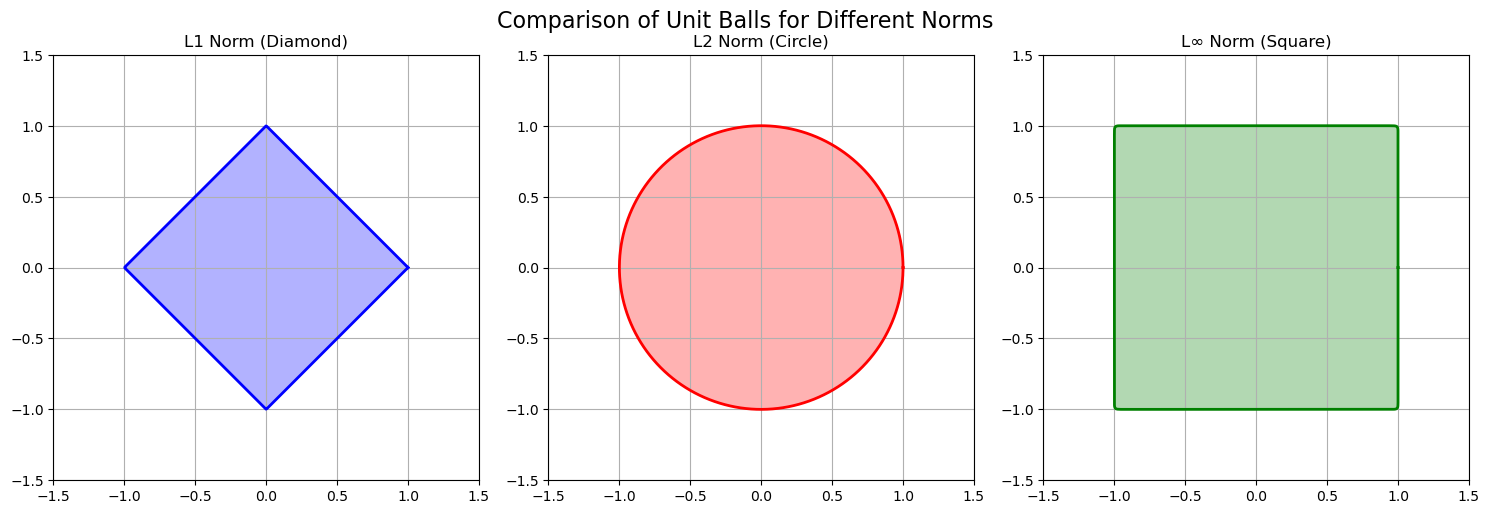

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 创建图形和子图
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparison of Unit Balls for Different Norms', fontsize=16)

# 生成角度值
theta = np.linspace(0, 2*np.pi, 1000)

# 1. 绘制 L1 范数 (曼哈顿范数) - 菱形
x1 = np.cos(theta)
y1 = np.sin(theta)
# 将极坐标转换为L1范数的单位球坐标
r1 = 1 / (np.abs(np.cos(theta)) + np.abs(np.sin(theta)))
x1_unit = r1 * np.cos(theta)
y1_unit = r1 * np.sin(theta)

axes[0].plot(x1_unit, y1_unit, 'b-', linewidth=2)
axes[0].fill(x1_unit, y1_unit, alpha=0.3, color='blue')
axes[0].set_title('L1 Norm (Diamond)')
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)
axes[0].grid(True)
axes[0].set_aspect('equal')

# 2. 绘制 L2 范数 (欧几里得范数) - 圆形
x2 = np.cos(theta)
y2 = np.sin(theta)

axes[1].plot(x2, y2, 'r-', linewidth=2)
axes[1].fill(x2, y2, alpha=0.3, color='red')
axes[1].set_title('L2 Norm (Circle)')
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].grid(True)
axes[1].set_aspect('equal')

# 3. 绘制 L∞ 范数 (最大范数) - 正方形
# 创建一个近似的正方形
p = 100  # 使用一个较大的p值来近似L∞范数
r_inf = 1 / (np.abs(np.cos(theta))**p + np.abs(np.sin(theta))**p)**(1/p)
x_inf_unit = r_inf * np.cos(theta)
y_inf_unit = r_inf * np.sin(theta)

axes[2].plot(x_inf_unit, y_inf_unit, 'g-', linewidth=2)
axes[2].fill(x_inf_unit, y_inf_unit, alpha=0.3, color='green')
axes[2].set_title('L∞ Norm (Square)')
axes[2].set_xlim(-1.5, 1.5)
axes[2].set_ylim(-1.5, 1.5)
axes[2].grid(True)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

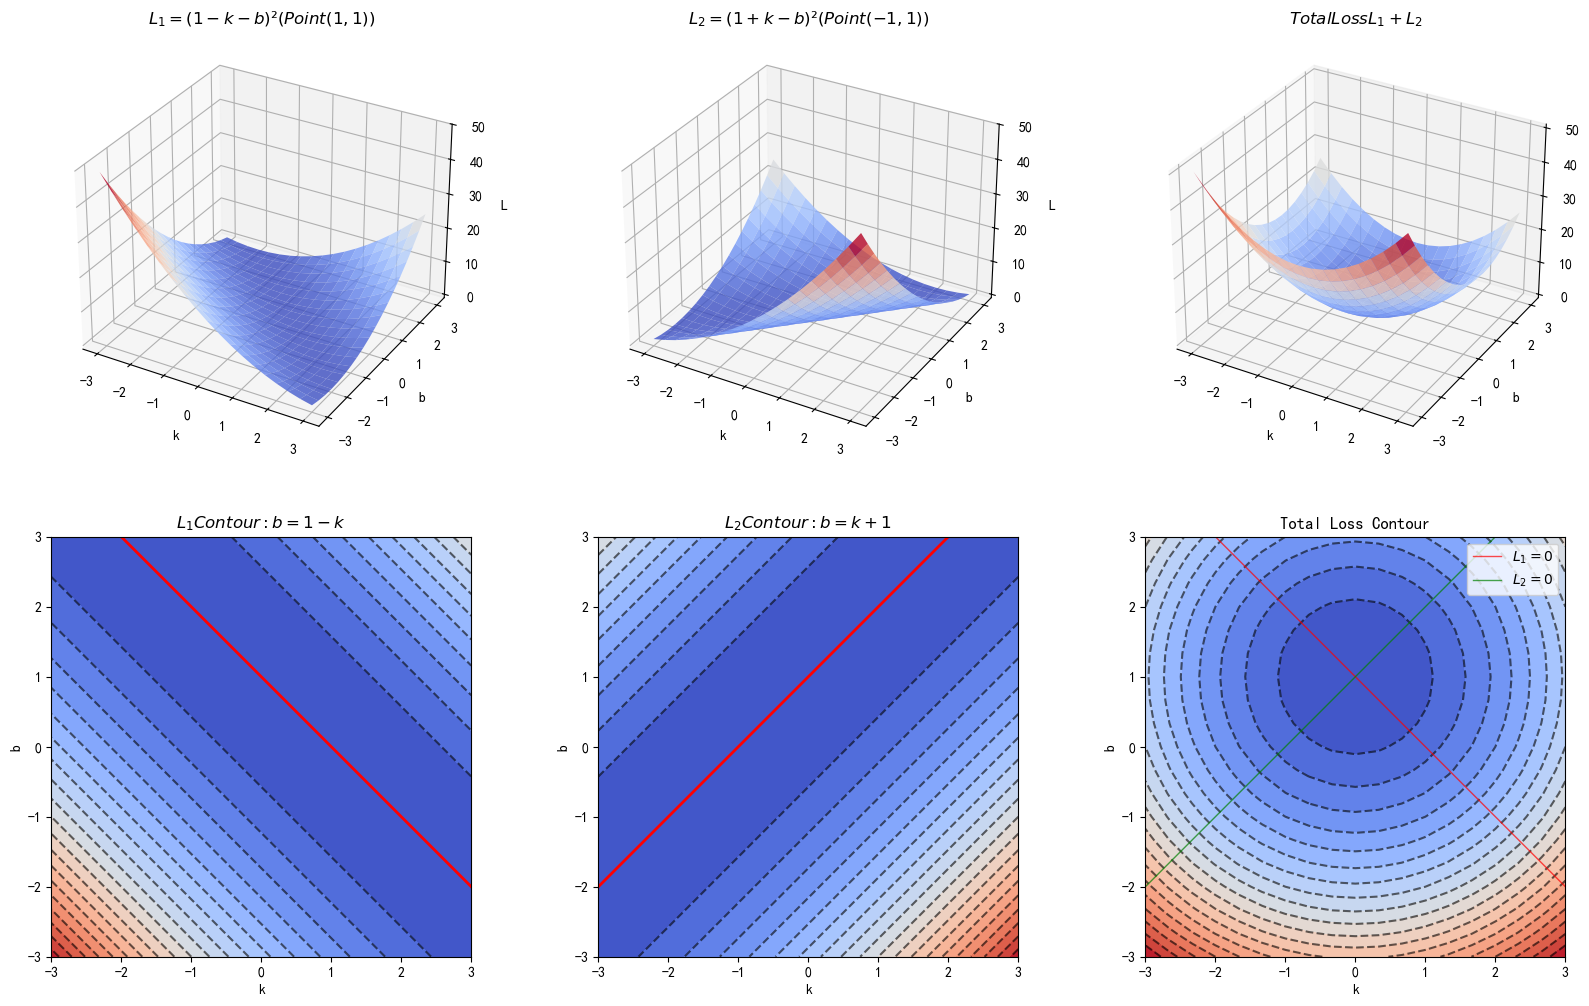

In [10]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 19)
b = np.linspace(-3, 3, 19)
K, B = np.meshgrid(k, b)

L1 = (1 - K - B)**2  # 对应点(1,1)    b = 1 - k
L2 = (1 + K - B)**2  # 对应点(-1,1)   b = -k - 1

# 四个点的总损失函数
L_total = L1 + L2 

# 创建图形
fig = plt.figure(figsize=(20, 12))

# 第一个点的损失函数
ax1 = fig.add_subplot(231, projection='3d')
surf1 = ax1.plot_surface(K, B, L1, cmap=cm.coolwarm, alpha=0.8)
ax1.set_xlabel('k')
ax1.set_ylabel('b')
ax1.set_zlabel('L')
ax1.set_title('$L_1 = (1 - k - b)² (Point (1,1))$')

# 第二个点的损失函数
ax2 = fig.add_subplot(232, projection='3d')
surf2 = ax2.plot_surface(K, B, L2, cmap=cm.coolwarm, alpha=0.8)
ax2.set_xlabel('k')
ax2.set_ylabel('b')
ax2.set_zlabel('L')
ax2.set_title('$L_2 = (1 + k - b)² (Point (-1,1))$')


# 四个点之和的损失函数
ax5 = fig.add_subplot(233, projection='3d')
surf5 = ax5.plot_surface(K, B, L_total, cmap=cm.coolwarm, alpha=0.8)
ax5.set_xlabel('k')
ax5.set_ylabel('b')
ax5.set_zlabel('L_total')
ax5.set_title('$Total Loss L_1 + L_2$')

x_line = np.linspace(-3, 3, 100)

# 第一个点的等高线
ax6 = fig.add_subplot(234)
contour1 = ax6.contour(K, B, L1, 20, colors='black', linestyles='dashed', alpha=0.6)
ax6.contourf(K, B, L1, 20, cmap=cm.coolwarm)
ax6.set_xlabel('k')
ax6.set_ylabel('b')
ax6.set_title('$L_1 Contour: b = 1 - k$')
# 绘制零损失线
ax6.plot(x_line, 1 - x_line, 'r-', linewidth=2)
ax6.set_ylim(-3, 3)
ax6.set_aspect("equal")

# 第二个点的等高线
ax7 = fig.add_subplot(235)
contour2 = ax7.contour(K, B, L2, 20, colors='black', linestyles='dashed', alpha=0.6)
ax7.contourf(K, B, L2, 20, cmap=cm.coolwarm)
ax7.set_xlabel('k')
ax7.set_ylabel('b')
ax7.set_title('$L_2 Contour: b = k + 1$')
# 绘制零损失线
ax7.plot(x_line, x_line + 1, 'r-', linewidth=2)
ax7.set_ylim(-3, 3)
ax7.set_aspect("equal")

# 总损失函数的等高线
ax10 = fig.add_subplot(2, 3, 6)
contour_total = ax10.contour(K, B, L_total, 20, colors='black', linestyles='dashed', alpha=0.6)
ax10.contourf(K, B, L_total, 20, cmap=cm.coolwarm)
ax10.set_xlabel('k')
ax10.set_ylabel('b')
ax10.set_title('Total Loss Contour')
# 绘制所有零损失线
ax10.plot(x_line, 1 - x_line, 'r-', linewidth=1, alpha=0.7, label='$L_1=0$')
ax10.plot(x_line, x_line + 1, 'g-', linewidth=1, alpha=0.7, label='$L_2=0$')
ax10.legend(loc='upper right')
ax10.set_ylim(-3, 3)
ax10.set_aspect("equal")

# plt.tight_layout()
plt.show()

### L1正则化-Lasso

$$
L_{Lasso}(\mathbf{w}, b) = \frac{1}{N}\sum_{i=1}^{N}(y_i - (\mathbf{w}^T \mathbf{x}_i + b))^2 + \lambda \sum_{j=1}^{p} |w_j|
$$

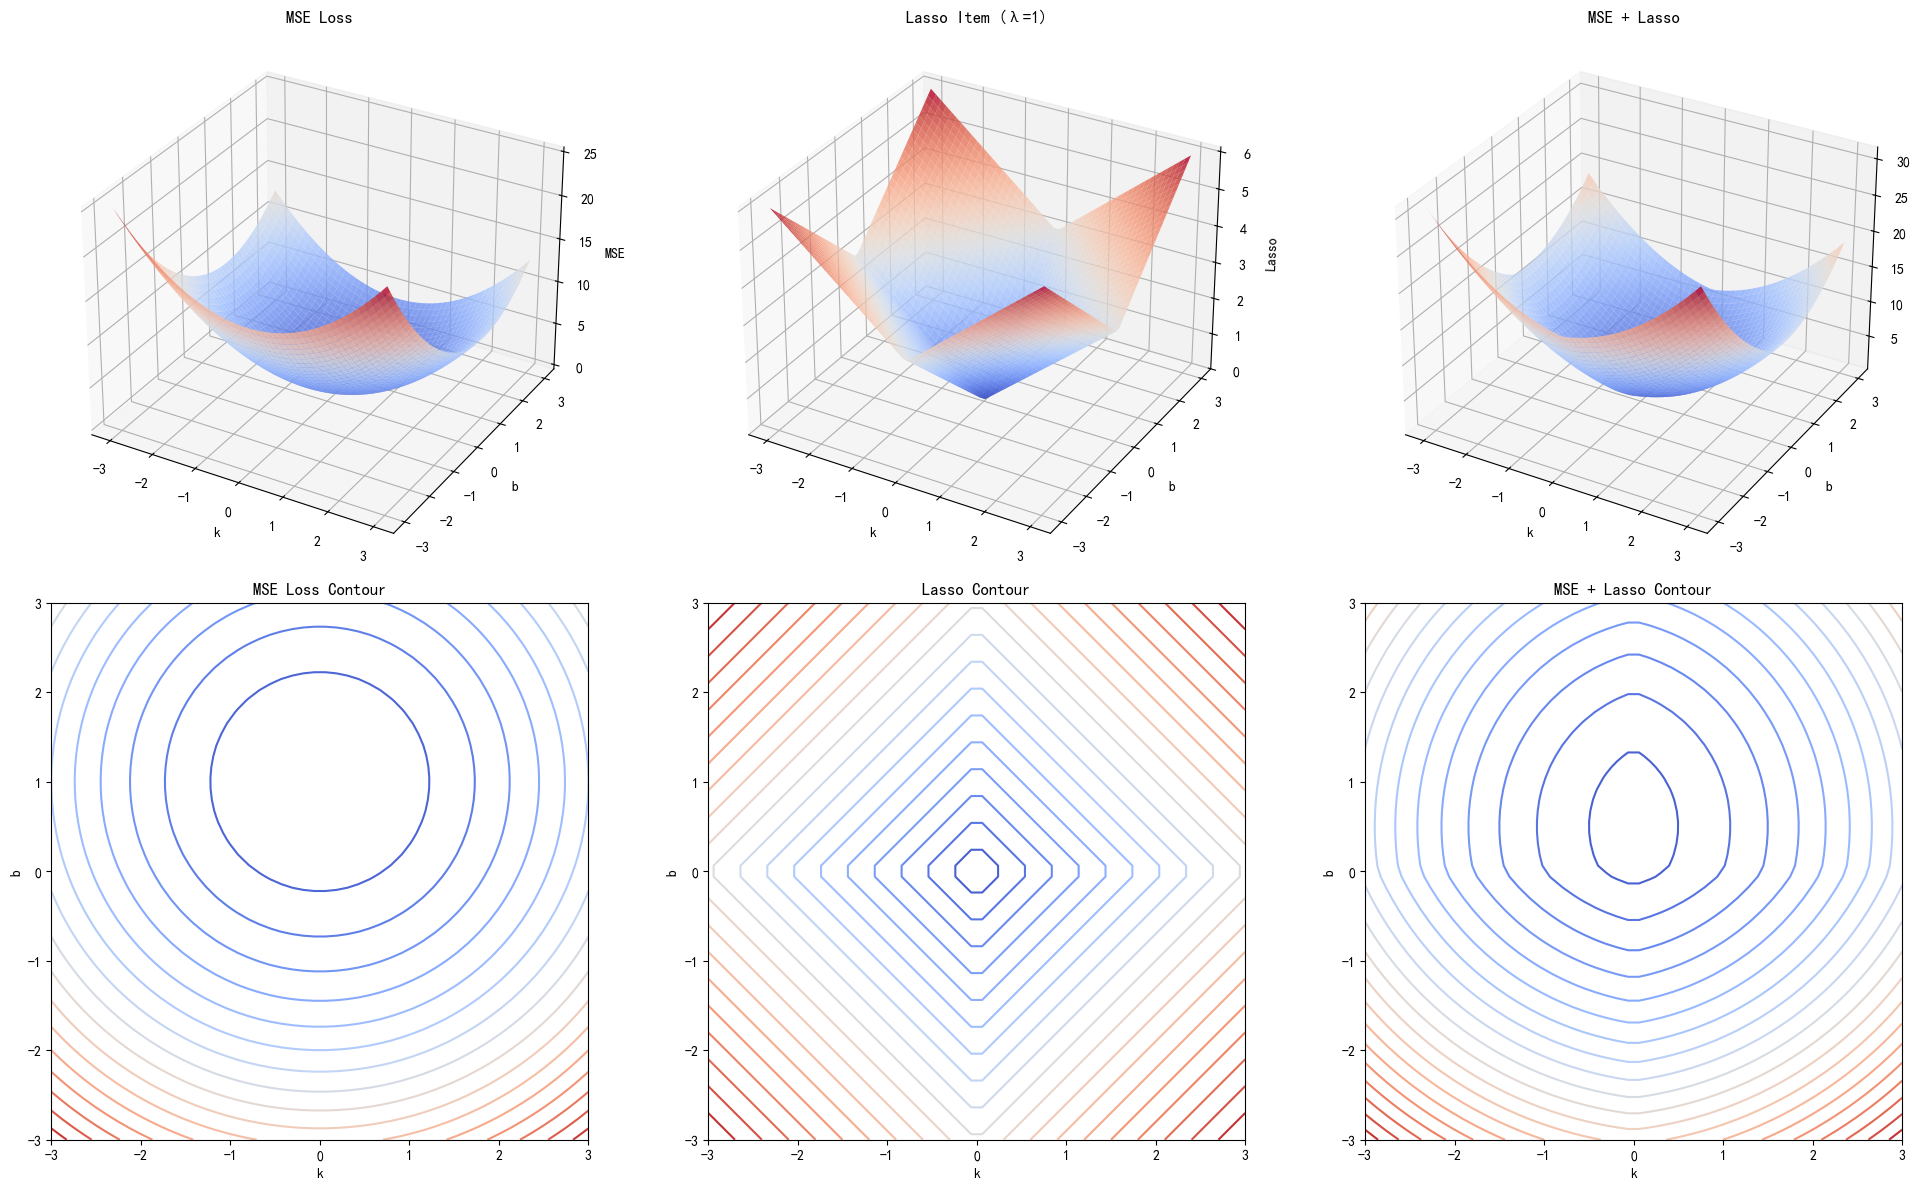

In [11]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 50)
b = np.linspace(-3, 3, 50)
K, B = np.meshgrid(k, b)

L1 = (1 - K - B)**2  # 对应点(1,1)    b = 1 - k
L2 = (1 + K - B)**2  # 对应点(-1,1)   b = -k - 1

# 四个点的总损失函数
MSE = (L1 + L2)/2

# 正则化参数
lambda_l1 = 1  # Lasso正则化系数
lambda_l2 = 1  # Ridge正则化系数

# 添加正则化项
lasso = lambda_l1 * (np.abs(K) + np.abs(B))
# ridge = lambda_l2 * (K**2 + B**2)

# MSE + Lasso
MSE_Lasso = MSE + lasso

# 创建图形
fig = plt.figure(figsize=(20, 12))

# MSE Loss 3D图
ax1 = fig.add_subplot(231, projection='3d')
surf1 = ax1.plot_surface(K, B, MSE, cmap=cm.coolwarm, alpha=0.8)
ax1.set_xlabel('k')
ax1.set_ylabel('b')
ax1.set_zlabel('MSE')
ax1.set_title('MSE Loss')

# Lasso (L1正则化) 3D图
ax2 = fig.add_subplot(232, projection='3d')
surf2 = ax2.plot_surface(K, B, lasso, cmap=cm.coolwarm, alpha=0.8)
ax2.set_xlabel('k')
ax2.set_ylabel('b')
ax2.set_zlabel('Lasso')
ax2.set_title(f'Lasso Item (λ={lambda_l1})')

# MSE + Lasso 3D图
ax3 = fig.add_subplot(233, projection='3d')
surf3 = ax3.plot_surface(K, B, MSE_Lasso, cmap=cm.coolwarm, alpha=0.8)
ax3.set_xlabel('k')
ax3.set_ylabel('b')
ax3.set_zlabel('MSE + Lasso')
ax3.set_title('MSE + Lasso')

# MSE Loss 等高线图
ax4 = fig.add_subplot(234)
contour1 = ax4.contour(K, B, MSE, 20, cmap=cm.coolwarm)
ax4.set_xlabel('k')
ax4.set_ylabel('b')
ax4.set_title('MSE Loss Contour')
ax4.set_aspect("equal")

# Lasso 等高线图
ax5 = fig.add_subplot(235)
contour2 = ax5.contour(K, B, lasso, 20, cmap=cm.coolwarm)
ax5.set_xlabel('k')
ax5.set_ylabel('b')
ax5.set_title('Lasso Contour')
ax5.set_aspect("equal")

# MSE + Lasso 等高线图
ax6 = fig.add_subplot(236)
contour3 = ax6.contour(K, B, MSE_Lasso, 20, cmap=cm.coolwarm)
ax6.set_xlabel('k')
ax6.set_ylabel('b')
ax6.set_title('MSE + Lasso Contour')
ax6.set_aspect("equal")

plt.tight_layout()
plt.show()

### L2正则化-Ridge

$$
L_{Ridge}(\mathbf{w}, b) = \frac{1}{N}\sum_{i=1}^{N}(y_i - (\mathbf{w}^T \mathbf{x}_i + b))^2 + \lambda \sum_{j=1}^{p} w_j^2
$$

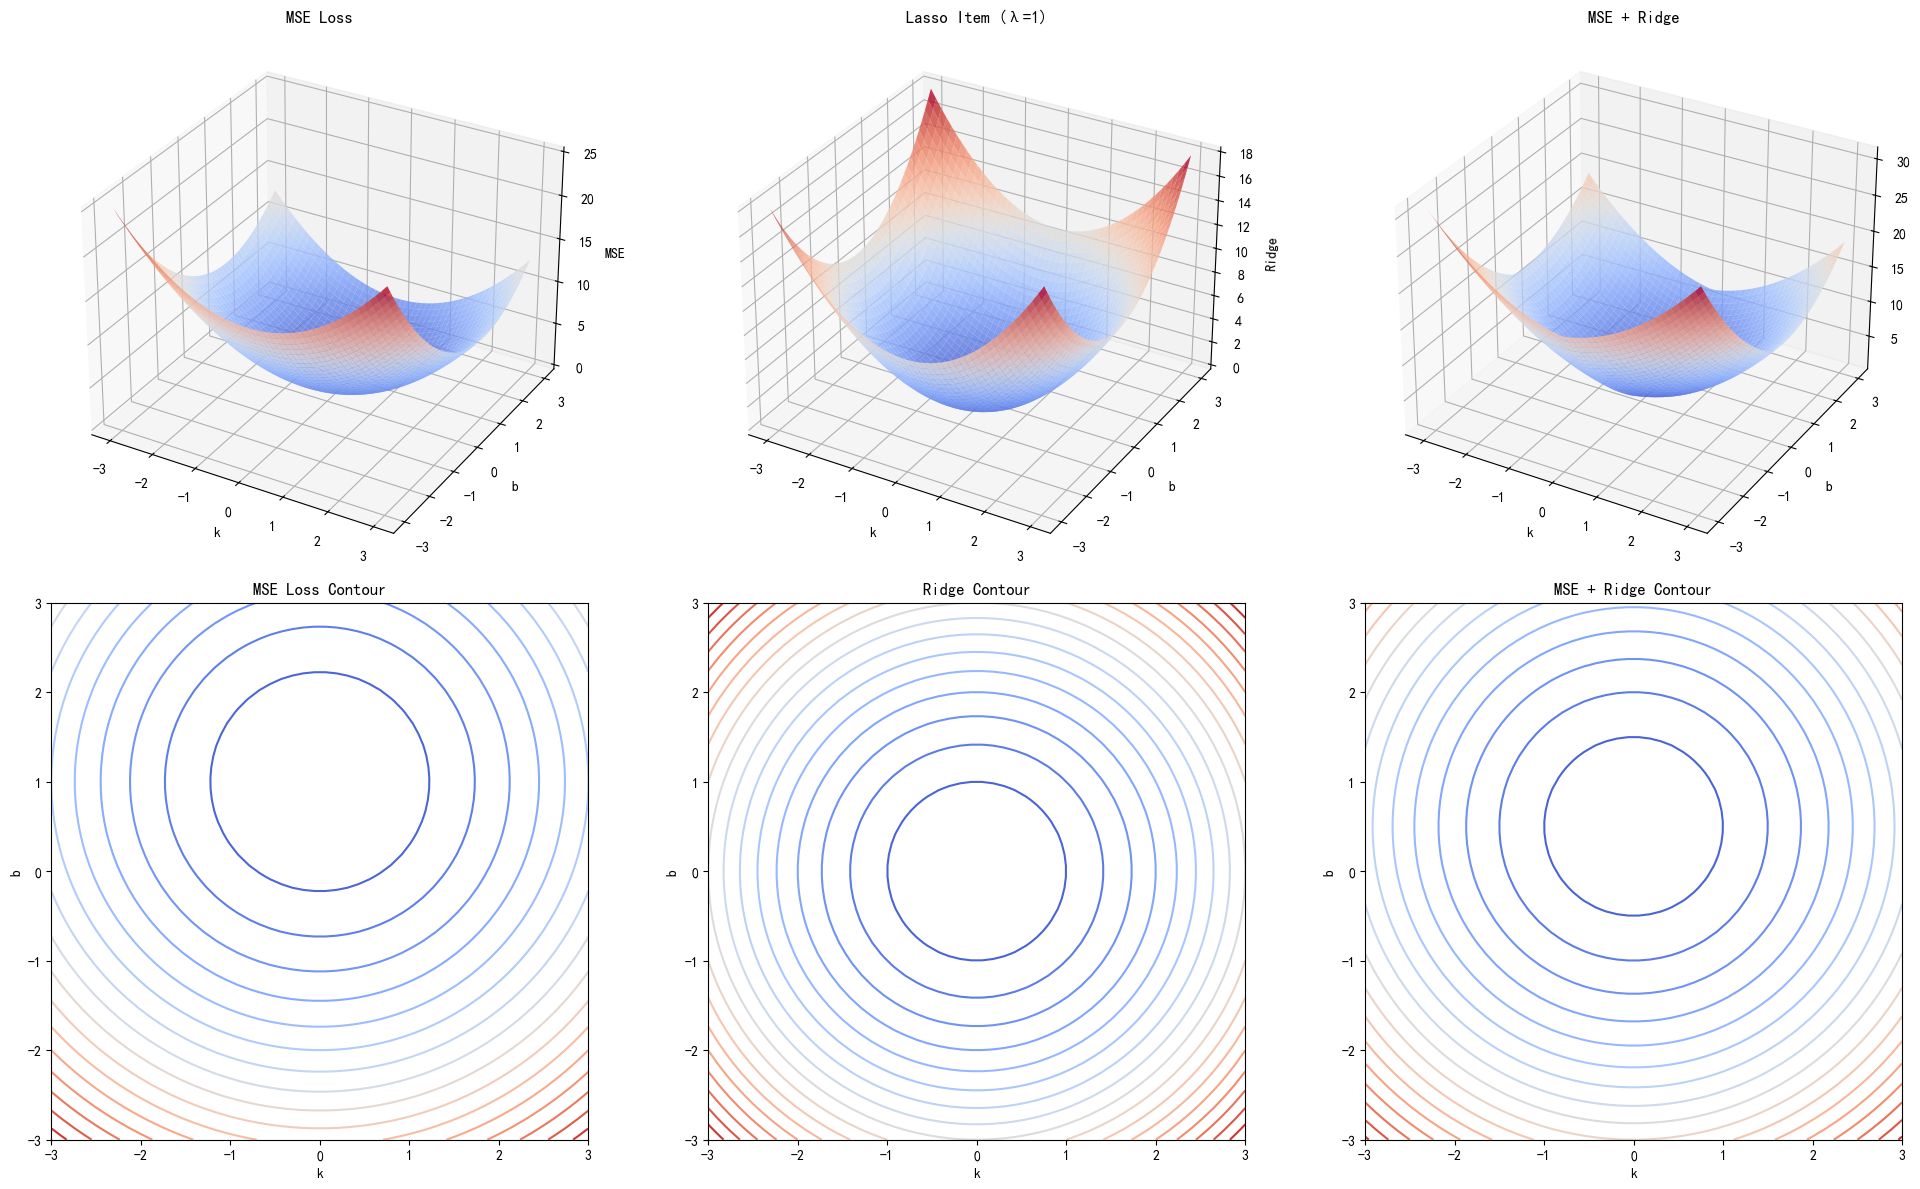

In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# 设置参数范围
k = np.linspace(-3, 3, 50)
b = np.linspace(-3, 3, 50)
K, B = np.meshgrid(k, b)

L1 = (1 - K - B)**2  # 对应点(1,1)    b = 1 - k
L2 = (1 + K - B)**2  # 对应点(-1,1)   b = -k - 1

# 四个点的总损失函数
MSE = (L1 + L2)/2

# 正则化参数
lambda_l1 = 1  # Lasso正则化系数
lambda_l2 = 1  # Ridge正则化系数

# 添加正则化项
# lasso = lambda_l1 * (np.abs(K) + np.abs(B))
ridge = lambda_l2 * (K**2 + B**2)

# MSE + ridge
MSE_Ridge = MSE + ridge

# 创建图形
fig = plt.figure(figsize=(20, 12))

# MSE Loss 3D图
ax1 = fig.add_subplot(231, projection='3d')
surf1 = ax1.plot_surface(K, B, MSE, cmap=cm.coolwarm, alpha=0.8)
ax1.set_xlabel('k')
ax1.set_ylabel('b')
ax1.set_zlabel('MSE')
ax1.set_title('MSE Loss')

# Lasso (L1正则化) 3D图
ax2 = fig.add_subplot(232, projection='3d')
surf2 = ax2.plot_surface(K, B, ridge, cmap=cm.coolwarm, alpha=0.8)
ax2.set_xlabel('k')
ax2.set_ylabel('b')
ax2.set_zlabel('Ridge')
ax2.set_title(f'Lasso Item (λ={lambda_l1})')

# MSE + Lasso 3D图
ax3 = fig.add_subplot(233, projection='3d')
surf3 = ax3.plot_surface(K, B, MSE_Lasso, cmap=cm.coolwarm, alpha=0.8)
ax3.set_xlabel('k')
ax3.set_ylabel('b')
ax3.set_zlabel('MSE + Ridge')
ax3.set_title('MSE + Ridge')

# MSE Loss 等高线图
ax4 = fig.add_subplot(234)
contour1 = ax4.contour(K, B, MSE, 20, cmap=cm.coolwarm)
ax4.set_xlabel('k')
ax4.set_ylabel('b')
ax4.set_title('MSE Loss Contour')
ax4.set_aspect("equal")

# Ridge 等高线图
ax5 = fig.add_subplot(235)
contour2 = ax5.contour(K, B, ridge, 20, cmap=cm.coolwarm)
ax5.set_xlabel('k')
ax5.set_ylabel('b')
ax5.set_title('Ridge Contour')
ax5.set_aspect("equal")

# MSE + Ridge 等高线图
ax6 = fig.add_subplot(236)
contour3 = ax6.contour(K, B, MSE_Ridge, 20, cmap=cm.coolwarm)
ax6.set_xlabel('k')
ax6.set_ylabel('b')
ax6.set_title('MSE + Ridge Contour')
ax6.set_aspect("equal")

plt.tight_layout()
plt.show()

## 动量法

### 小批量梯度下降(mini-batch GD)

初始参数: k = -3.00, b = -3.00
Epoch 1, Batch 1: k = -3.00, b = -3.00, 批次损失 = 1.00
Epoch 1, Batch 2: k = -2.30, b = -2.30, 批次损失 = 24.50
Epoch 1 平均损失: 12.75
Epoch 2, Batch 1: k = -1.95, b = -1.95, 批次损失 = 1.00
Epoch 2, Batch 2: k = -1.28, b = -1.28, 批次损失 = 12.00
Epoch 2 平均损失: 6.50
Epoch 3, Batch 1: k = -0.50, b = -0.70, 批次损失 = 6.87
Epoch 3, Batch 2: k = -0.22, b = -0.28, 批次损失 = 0.72
Epoch 3 平均损失: 3.80
Epoch 4, Batch 1: k = -0.04, b = 0.18, 批次损失 = 1.69
Epoch 4, Batch 2: k = 0.17, b = 0.29, 批次损失 = 0.75
Epoch 4 平均损失: 1.22
Epoch 5, Batch 1: k = 0.45, b = 0.29, 批次损失 = 0.77
Epoch 5, Batch 2: k = 0.47, b = 0.40, 批次损失 = 0.67
Epoch 5 平均损失: 0.72


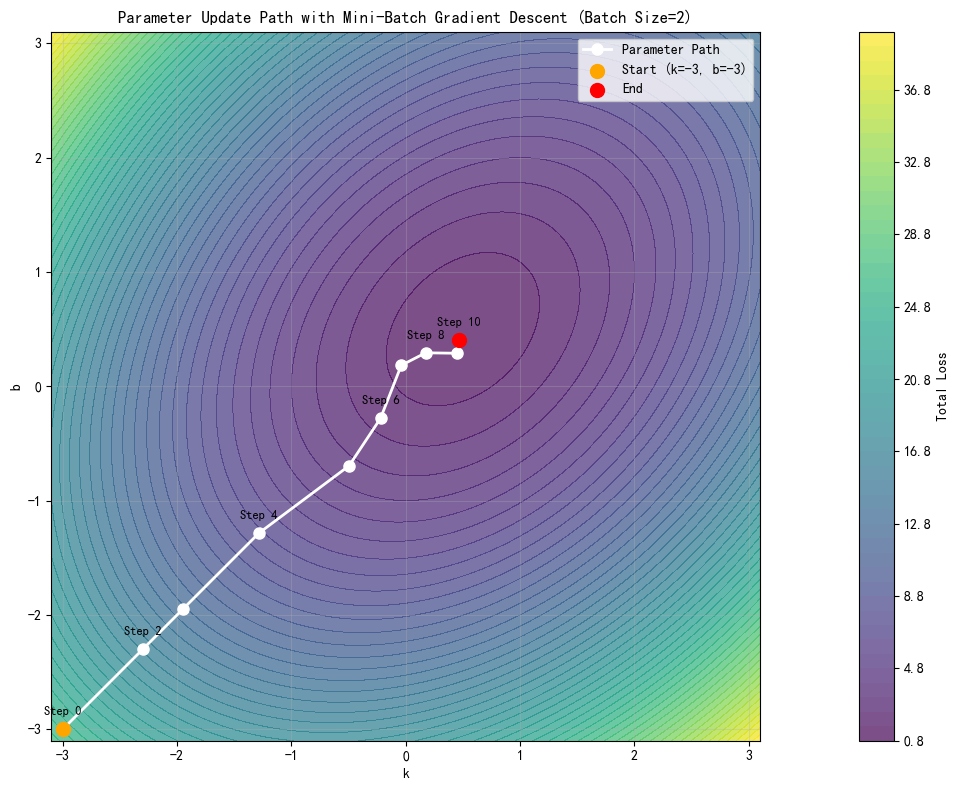


最终参数: k = 0.4657, b = 0.4025
最终总损失: 1.0115


In [15]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# 设置随机种子以确保结果可重现
torch.manual_seed(42)

# 定义四个数据点
points = torch.tensor([
    [1.0, 1.0],    # (x, y) = (1, 1)
    [-1.0, 1.0],   # (x, y) = (-1, 1)
    [-1.0, -1.0],  # (x, y) = (-1, -1)
    # [1.0, -1.0]    # (x, y) = (1, -1)
])

# 创建数据集和数据加载器，批次大小为2
dataset = TensorDataset(points[:, 0], points[:, 1])
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)

# 初始化参数
k = torch.tensor([-3.0], requires_grad=True)
b = torch.tensor([-3.0], requires_grad=True)

# 学习率
learning_rate = 0.1

# 存储参数更新路径
path = [(k.item(), b.item())]

# 创建优化器，只优化k和b
optimizer = optim.SGD([k, b], lr=learning_rate, momentum=0.5)

print("初始参数: k = {:.2f}, b = {:.2f}".format(k.item(), b.item()))

# 小批量梯度下降
num_epochs = 5
for epoch in range(num_epochs):
    epoch_loss = 0.0
    batch_count = 0
    
    for batch_x, batch_y in dataloader:
        # 清零梯度
        optimizer.zero_grad()
        
        # 计算当前批次的预测值
        y_pred = k * batch_x + b
        
        # 计算当前批次的损失
        loss = torch.sum((y_pred - batch_y) ** 2)/2
        
        # 反向传播
        loss.backward()
        
        # 更新参数
        optimizer.step()
        
        # 记录参数
        path.append((k.item(), b.item()))
        
        epoch_loss += loss.item()
        batch_count += 1
        
        print("Epoch {}, Batch {}: k = {:.2f}, b = {:.2f}, 批次损失 = {:.2f}".format(
            epoch+1, batch_count, k.item(), b.item(), loss.item()))
    
    print("Epoch {} 平均损失: {:.2f}".format(epoch+1, epoch_loss / batch_count))

# 将路径转换为numpy数组以便绘图
path = np.array(path)

# 绘制参数更新路径
plt.figure(figsize=(20, 8))

# 绘制等高线
k_vals = np.linspace(-3.1, 3.1, 100)
b_vals = np.linspace(-3.1, 3.1, 100)
K, B = np.meshgrid(k_vals, b_vals)

# 计算总损失
L_total = np.zeros_like(K)
for point in points:
    x, y_true = point
    L_total += (K * x.item() + B - y_true.item()) ** 2
L_total = L_total/2

# 绘制等高线图
plt.contourf(K, B, L_total, 50, cmap='viridis', alpha=0.7)
plt.colorbar(label='Total Loss')

# 绘制参数更新路径
plt.plot(path[:, 0], path[:, 1], 'wo-', markersize=8, linewidth=2, label='Parameter Path')
plt.scatter(path[0, 0], path[0, 1], c='orange', s=100, label='Start (k=-3, b=-3)', zorder=10)
plt.scatter(path[-1, 0], path[-1, 1], c='red', s=100, label='End', zorder=10)

# 标记关键步骤
for i, (k_val, b_val) in enumerate(path):
    if i == 0 or i == len(path)-1 or i % 2 == 0:  # 只标记起始点、结束点和每两个批次
        plt.annotate(f'Step {i}', (k_val, b_val), textcoords="offset points", 
                     xytext=(0,10), ha='center', fontsize=9)

# 设置图形属性
plt.xlabel('k')
plt.ylabel('b')
plt.title('Parameter Update Path with Mini-Batch Gradient Descent (Batch Size=2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(-3.1, 3.1)
plt.ylim(-3.1, 3.1)
plt.gca().set_aspect('equal')

plt.tight_layout()
plt.show()

# 打印最终结果
print("\n最终参数: k = {:.4f}, b = {:.4f}".format(k.item(), b.item()))
print("最终总损失: {:.4f}".format(L_total[np.abs(b_vals - b.item()).argmin(), 
                                np.abs(k_vals - k.item()).argmin()]))

## 模型的参数

自变量，导数值、优化器参数